# `fit_v5_peaks`: landmark-point model of the OT amplitude, all 8 sims

Alternative to `fit_v5_all.ipynb`'s PCA-coefficient model. Instead of decomposing each OT
displacement curve `T(r)-r` into 3 PCA amplitude coefficients, this tracks **3 role-based
landmark points** directly on the curve, each as an `(r, amplitude)` pair: the main **peak**
(the largest bootstrap-significant local max), and the nearest significant turning points
**inner**/**outer** to it (before/after in radius; amplitude 0 if none is significant there).
That's 6 numbers per curve, each modeled as its own function of `(log M, z)` -- 6 functions
total, vs. the PCA model's 3 PCA-coefficient functions.

**Why role-based, not "sorted by radius."** The first version of this notebook assigned
`r1 < r2 < r3` purely by radius rank (whichever significant point was innermost = `r1`, etc.).
That broke down where the main peak isn't significant at low mass -- `r1` would hold the inner
*trough* there (rising smoothly toward 0 with mass), then abruptly switch to holding the main
*peak* once it exceeds the bootstrap threshold (falling with mass from a jump) -- two different
physical quantities stitched into one series, with a hard jump at the crossover mass. Assigning
by role instead (`peak` is always "the main peak," never a trough) fixed this: `y_peak(M,z)`
comes out as one clean, smooth, monotonic curve, and `y_inner`/`y_outer` smoothly approach 0 as
their feature drops below the noise instead of discontinuously swapping identity with `y_peak`.

**Ordering.** `r_inner <= r_peak <= r_outer` by construction (they're defined relative to the
peak's position, not independently), so the same `r_peak = f(M,z)`, `r_outer = r_peak + g(M,z)`
(`g>=0` enforced e.g. via `softplus`), `r_inner = r_peak - h(M,z)` (`h>=0`) trick can still be
used when fitting, to guarantee the fitted functions can't cross.

This notebook starts with the exploratory step: detect these landmark points on the real curves
(using the same bin selection as `fit_v5_all.ipynb`) and look at how each varies with `(log M,
z)`, before committing to analytic functional forms.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams.update({
    "font.size": 16, "axes.titlesize": 18, "axes.labelsize": 16,
    "legend.fontsize": 13, "xtick.labelsize": 13, "ytick.labelsize": 13,
    "figure.titlesize": 20, "figure.dpi": 75,
})
import h5py
from scipy.signal import savgol_filter, find_peaks

PATH = "/Users/jpaine/Desktop/Flamingo/"
SNAP_Z = {9:5.,13:4.,17:3.,37:2.,47:1.5,57:1.,62:.75,67:.5,69:.4,71:.3,73:.2,75:.1,77:0.}
SIMS = ["fgas+2sigma", "fgas-2sigma", "fgas-4sigma", "fgas-8sigma",
        "Mstar-1sigma", "Mstar-1sigma_fgas-4sigma", "Jet", "Jet_fgas-4sigma"]

f5 = h5py.File(f"{PATH}profiles_v5_10k.hdf5", "r")
n5 = sum(len(f5[s][sim]) for s in f5 for sim in f5[s])
print(f"v5: {n5} bins across {sum(1 for s in f5 for sim in f5[s])} snap/sim combos")

v5: 4160 bins across 104 snap/sim combos


## Bin selection

Identical cut to `fit_v5_fgas.ipynb`: `status=="ok"`, `ot_reliable`, `n_halos >= 10000` below
the NMAX-capped mass (per snap/sim), `n_halos >= 100` above it.

In [2]:
def peak_capped_mass(f, snap, sim, nmax=10000):
    los = [f[snap][sim][k].attrs["lo"] for k in f[snap][sim]
           if f[snap][sim][k].attrs.get("status") == "ok"
           and f[snap][sim][k].attrs.get("n_halos") == nmax]
    return max(los) if los else -np.inf

def select_bins(f=f5, sims=SIMS, nmin_low_mass=10000, nmin_high_mass=100):
    rows = []
    for snap in f:
        z = SNAP_Z.get(int(snap))
        if z is None:
            continue
        for sim in sims:
            if sim not in f[snap]:
                continue
            peak = peak_capped_mass(f, snap, sim)
            for key in f[snap][sim]:
                g = f[snap][sim][key]
                if g.attrs.get("status") != "ok" or not g.attrs.get("ot_reliable", False):
                    continue
                lo, hi, n = g.attrs["lo"], g.attrs["hi"], g.attrs["n_halos"]
                if not (n >= nmin_low_mass or (lo > peak and n >= nmin_high_mass)):
                    continue
                rows.append(dict(
                    sim=sim, snap=snap, z=z, lo=float(lo), hi=float(hi), logM=float(lo + hi) / 2,
                    n_halos=int(n), capped=bool(n == g.attrs["nmax"]),
                    rc=g["rc"][...], ot_amp=g["ot"][...] - g["rc"][...],
                ))
    return rows

bins_ = select_bins()
meta = pd.DataFrame(bins_)[["sim", "snap", "z", "logM", "n_halos", "capped"]]
print(f"{len(bins_)} bins pass the cut (of {n5} total in v5)")
meta.groupby("sim").size()

1519 bins pass the cut (of 4160 total in v5)


sim
Jet                         187
Jet_fgas-4sigma             190
Mstar-1sigma                190
Mstar-1sigma_fgas-4sigma    191
fgas+2sigma                 190
fgas-2sigma                 190
fgas-4sigma                 191
fgas-8sigma                 190
dtype: int64

## Bootstrap error, for a significance-based peak threshold

`bootstrap_v5.csv` gives a per-radius bootstrap std for every `status=="ok"` bin -- interpolated
onto `R_GRID` the same way the curves themselves are (`STD_GRID`), so a turning point can be
required to be a real, statistically significant feature (prominence above the local noise
level) rather than just "large relative to the whole curve's range."

In [3]:
R_GRID = np.geomspace(0.15, 4.85, 100)

def to_common_grid(b, r_grid=R_GRID):
    return np.interp(np.log(r_grid), np.log(b["rc"]), b["ot_amp"])

X = np.array([to_common_grid(b) for b in bins_])

boot_raw = pd.read_csv(f"{PATH}bootstrap_v5.csv")
boot_raw = boot_raw[boot_raw.sim.isin(SIMS)]
boot_lookup = {}
for (snap, sim, lo, hi), g in boot_raw.groupby(["snap", "sim", "lo", "hi"]):
    g = g.sort_values("r_idx")
    boot_lookup[(int(snap), sim, round(lo, 3), round(hi, 3))] = dict(
        rc=g["rc"].values, ot_std=g["ot_std_boot"].values)

STD_GRID = np.full_like(X, np.nan)
n_missing = 0
for i, b in enumerate(bins_):
    key = (int(b["snap"]), b["sim"], round(b["lo"], 3), round(b["hi"], 3))
    bh = boot_lookup.get(key)
    if bh is None:
        n_missing += 1
        continue
    STD_GRID[i] = np.interp(np.log(R_GRID), np.log(bh["rc"]), bh["ot_std"])

print(f"{len(bins_) - n_missing} of {len(bins_)} bins have a bootstrap match ({n_missing} missing)")

1519 of 1519 bins have a bootstrap match (0 missing)


## Turning-point detection

Each curve is lightly smoothed (`savgol_filter`) purely to suppress noise. `scipy.signal.
find_peaks` on the smoothed curve (maxima) and its negative (minima) finds every candidate
turning point with a minimum `distance` (grid points) between them; **prominence is then
required to exceed the bootstrap sigma at that radius** (`STD_GRID`, from the previous cell) --
a turning point only counts if it's a real feature sticking up above the halo-count noise, not
just a wiggle in the mean curve. Reported amplitude is read off the **unsmoothed** curve.

From the surviving significant turning points: **peak** = the one with the largest local-max
value (0 if no significant local max exists); **inner**/**outer** = the nearest significant
turning point before/after the peak in radius (0 if none). See the intro above for why this
role-based assignment replaced an earlier "sort by radius" version.

In [4]:
def find_landmark_points(y, std, r_grid=R_GRID, window=41, polyorder=3,
                          distance=10, sigma_mult=1.0):
    """Role-based landmark points: peak = largest-value significant local max (0 if none);
    inner/outer = nearest significant turning point (max or min) before/after the peak in
    radius (0 if none). A candidate turning point is significant if its prominence exceeds
    sigma_mult * the bootstrap std (std, aligned with r_grid) at that radius."""
    y_smooth = savgol_filter(y, window, polyorder)
    safe_std = np.nan_to_num(std, nan=np.inf)  # missing sigma -> never passes (can't confirm significance)

    maxima, prop_max = find_peaks(y_smooth, distance=distance, prominence=1e-12)
    minima, prop_min = find_peaks(-y_smooth, distance=distance, prominence=1e-12)
    all_idx = np.concatenate([maxima, minima])
    all_prom = np.concatenate([prop_max["prominences"], prop_min["prominences"]])
    is_max = np.concatenate([np.ones(len(maxima), bool), np.zeros(len(minima), bool)])

    sig = all_prom > sigma_mult * safe_std[all_idx]
    idx, is_max = all_idx[sig], is_max[sig]

    r_peak, y_peak = np.nan, 0.0
    r_in, y_in = np.nan, 0.0
    r_out, y_out = np.nan, 0.0
    if is_max.any():
        max_idx = idx[is_max]
        j = max_idx[np.argmax(y[max_idx])]
        r_peak, y_peak = r_grid[j], y[j]
        before, after = idx[idx < j], idx[idx > j]
        if len(before):
            jb = before.max()  # closest to the peak on the inside
            r_in, y_in = r_grid[jb], y[jb]
        if len(after):
            ja = after.min()  # closest to the peak on the outside
            r_out, y_out = r_grid[ja], y[ja]
    return (r_in, y_in), (r_peak, y_peak), (r_out, y_out)

peak_results = [find_landmark_points(y, STD_GRID[i]) for i, y in enumerate(X)]
n_real_peaks = np.array([sum(np.isfinite(pt[0]) for pt in pr) for pr in peak_results])

print("distribution of # significant landmark points per curve (of 3 roles: inner/peak/outer):")
print(pd.Series(n_real_peaks).value_counts().sort_index())
print(f"\n{len(bins_)} curves total")
print(f"curves with no significant peak at all: {sum(np.isnan(pr[1][0]) for pr in peak_results)}")

distribution of # significant landmark points per curve (of 3 roles: inner/peak/outer):
0     15
1    605
2    819
3     80
Name: count, dtype: int64

1519 curves total
curves with no significant peak at all: 15


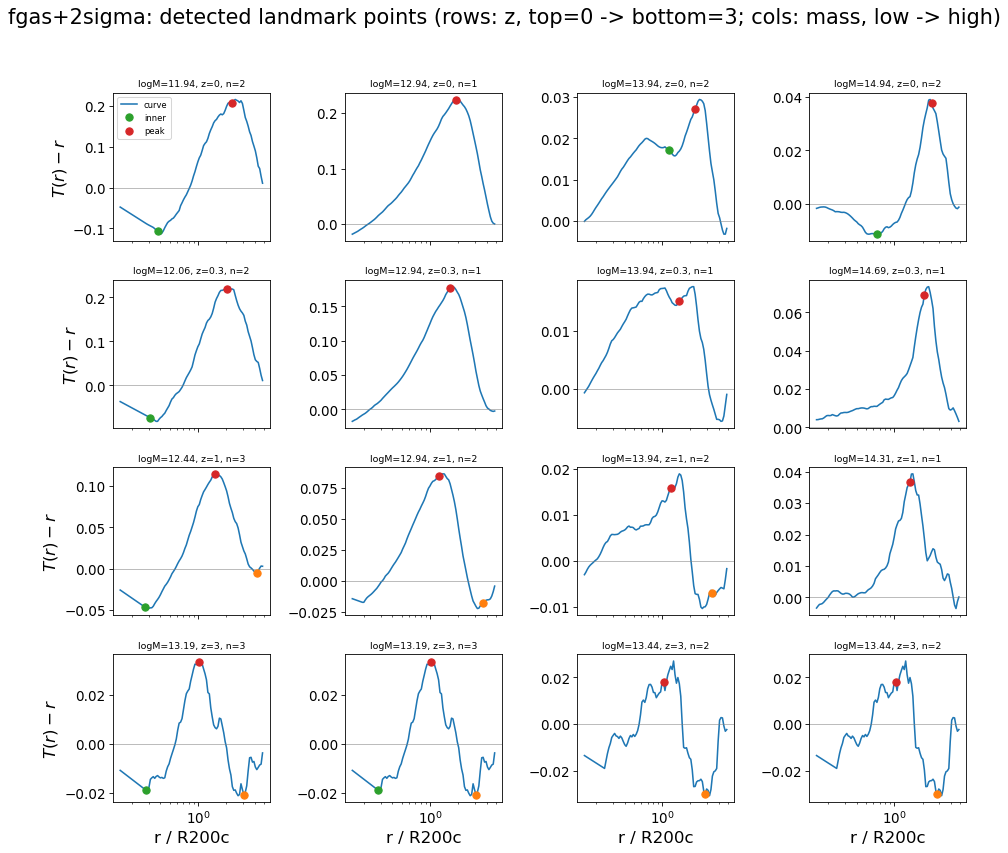

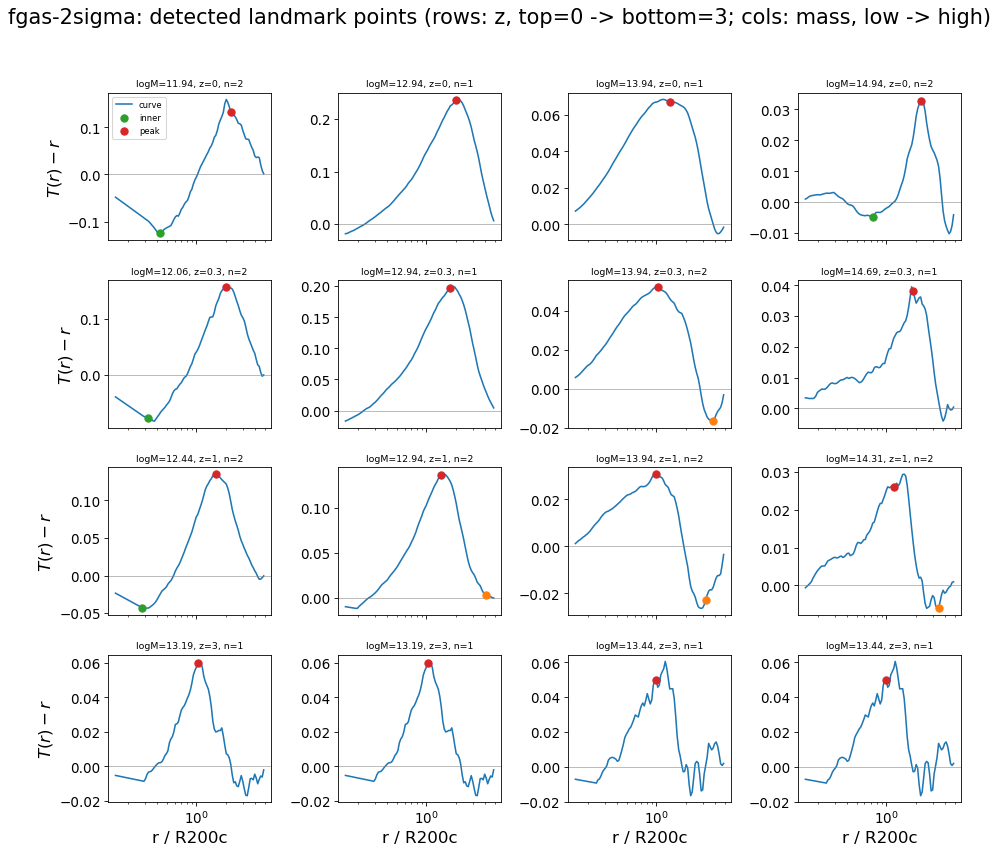

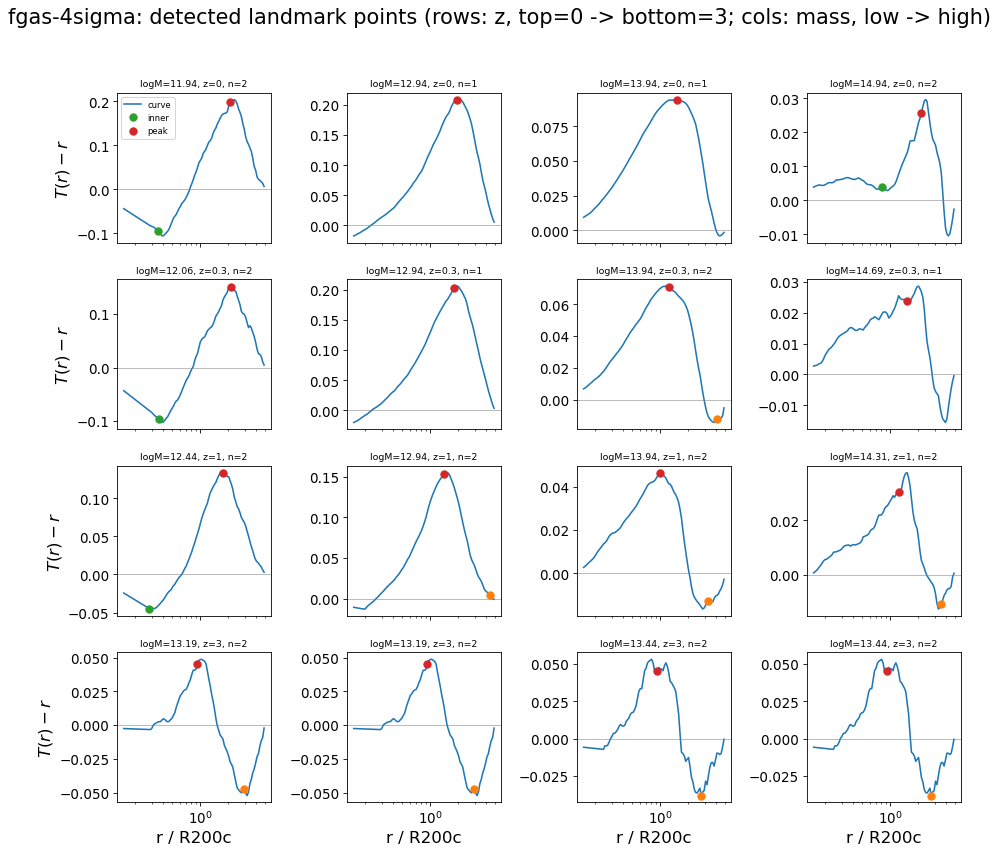

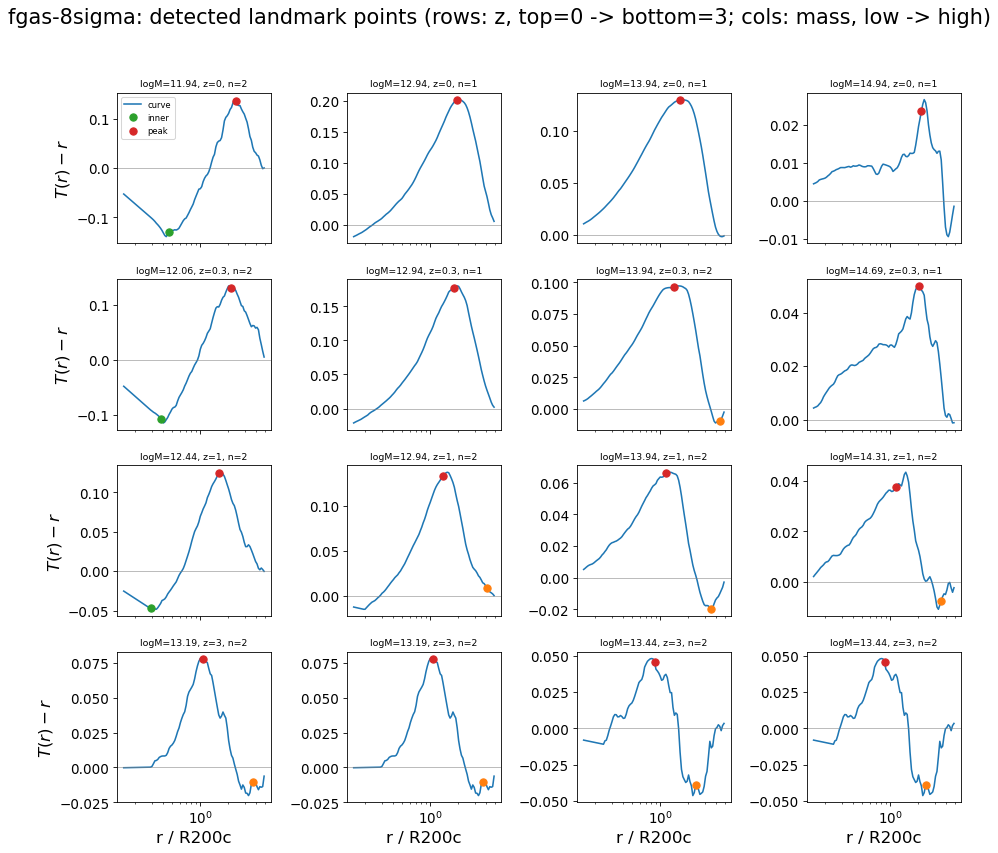

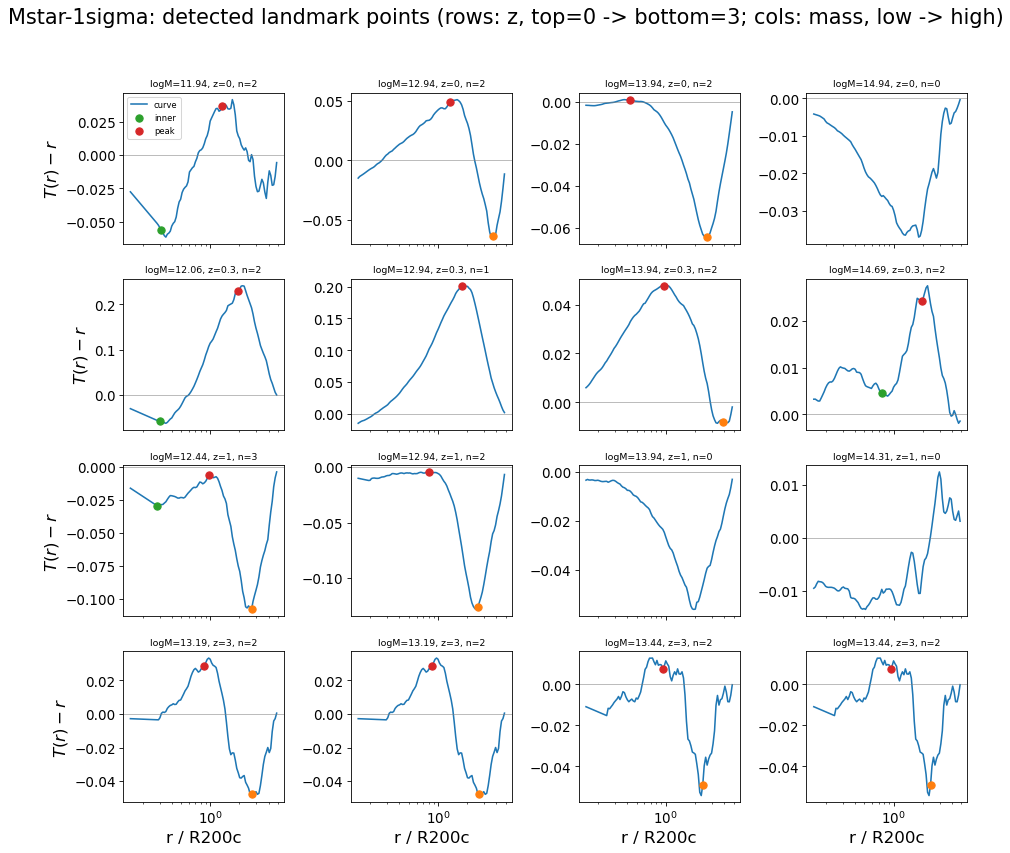

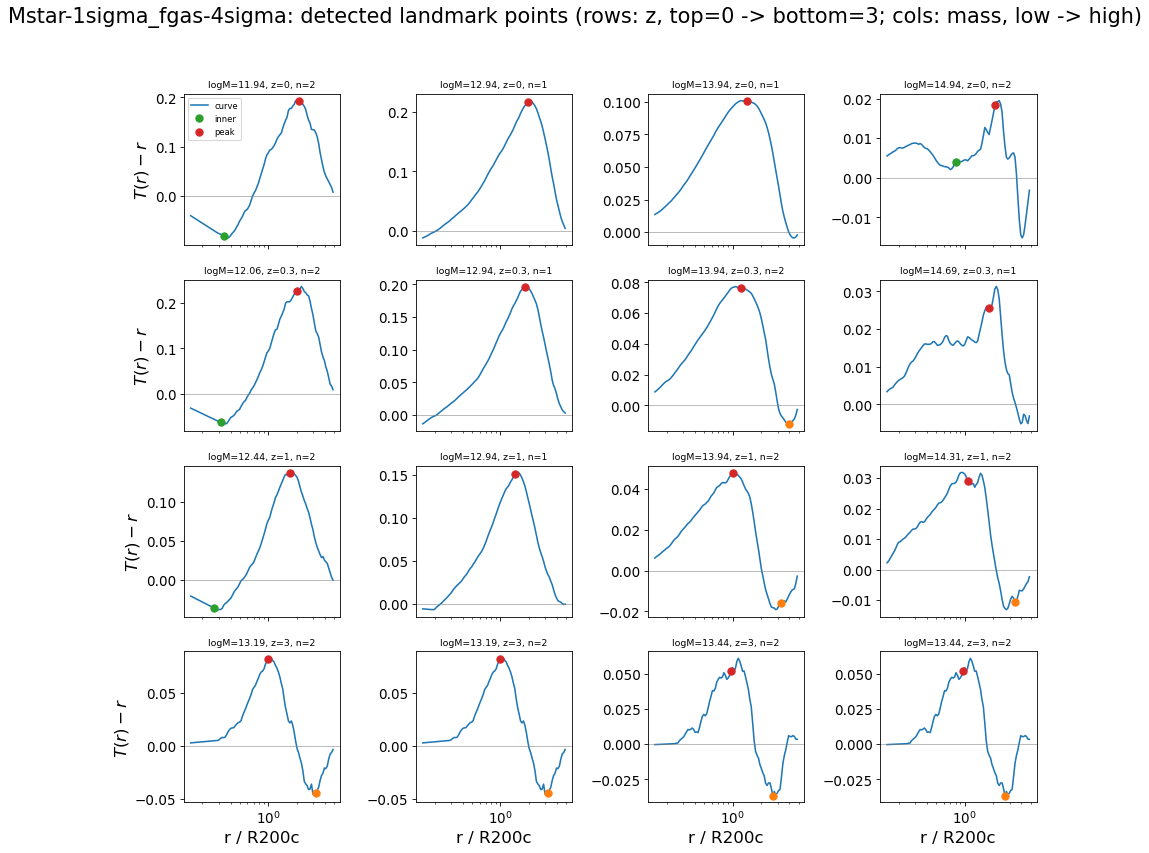

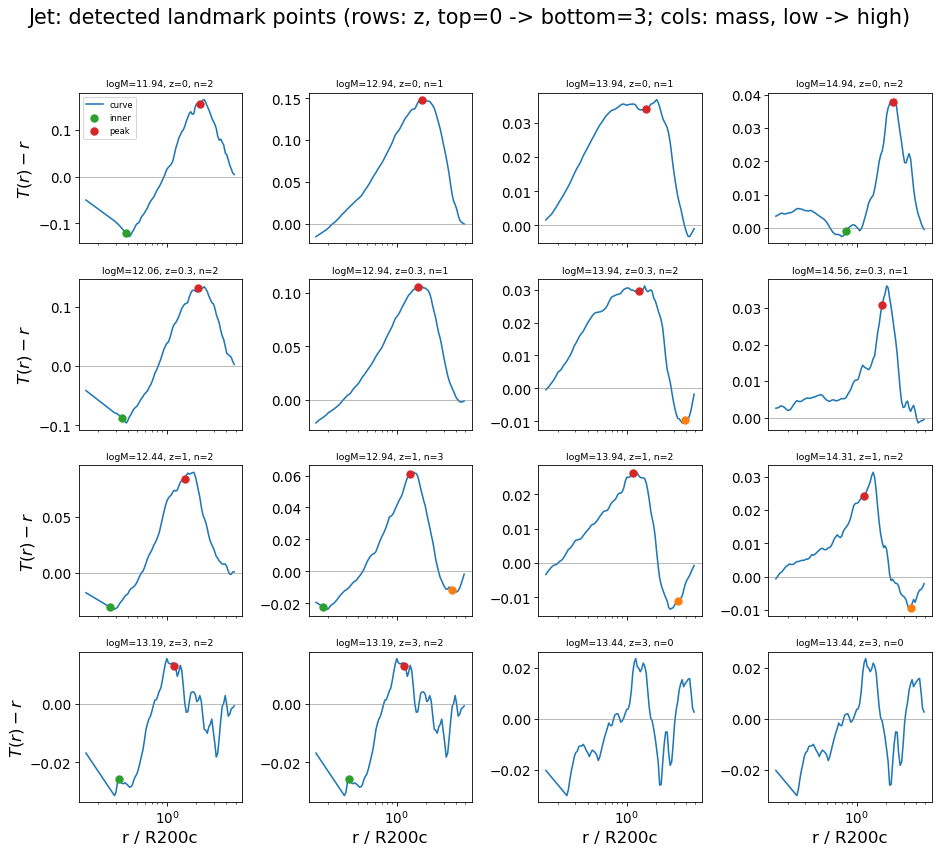

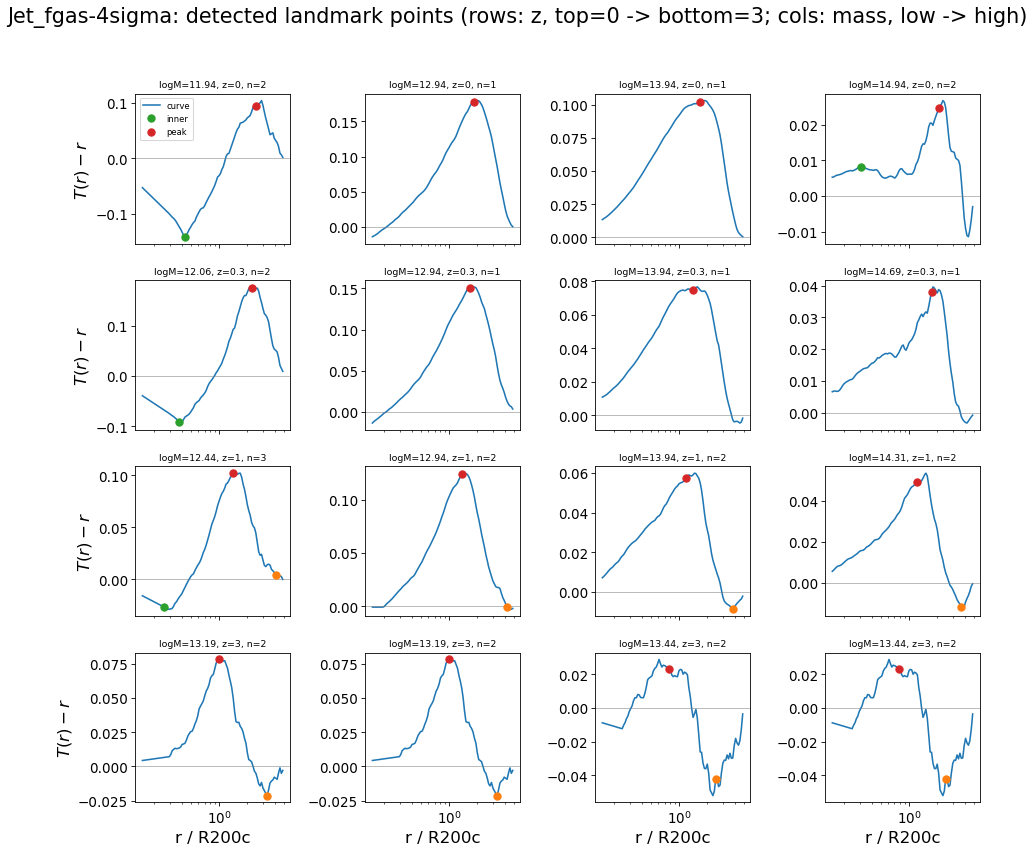

In [5]:
def plot_peak_examples(sim, n_mass=4, n_z=4, bins_=bins_, meta=meta):
    idx_sim = np.where((meta.sim == sim).values)[0]
    if len(idx_sim) == 0:
        print(f"no bins for {sim}"); return

    zs = sorted({bins_[i]["z"] for i in idx_sim})  # ascending: z=0 first (top row)
    z_targets = [zs[i] for i in sorted(set(np.linspace(0, len(zs)-1, min(n_z, len(zs))).round().astype(int)))]
    masses = sorted({bins_[i]["logM"] for i in idx_sim})  # ascending: low mass first (left col)
    m_targets = [masses[i] for i in sorted(set(np.linspace(0, len(masses)-1, min(n_mass, len(masses))).round().astype(int)))]

    nrows, ncols = len(z_targets), len(m_targets)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.8*nrows), sharex=True)
    axes = np.atleast_2d(axes)
    for i, z_t in enumerate(z_targets):
        for j, m_t in enumerate(m_targets):
            ax = axes[i, j]
            cand = [k for k in idx_sim if bins_[k]["z"] == z_t]
            if not cand:
                ax.axis("off"); continue
            k = min(cand, key=lambda k: abs(bins_[k]["logM"] - m_t))
            b = bins_[k]
            ax.plot(R_GRID, X[k], "-", color="C0", lw=1.5, label="curve")
            (r_in, y_in), (r_peak, y_peak), (r_out, y_out) = peak_results[k]
            for (r, y, c, lbl) in [(r_in, y_in, "C2", "inner"), (r_peak, y_peak, "C3", "peak"),
                                   (r_out, y_out, "C1", "outer")]:
                if np.isfinite(r):
                    ax.plot(r, y, "o", color=c, ms=7, zorder=3, label=lbl)
            ax.set_xscale("log"); ax.axhline(0, color="gray", lw=.5)
            n_real = sum(np.isfinite(pt[0]) for pt in peak_results[k])
            ax.set_title(f"logM={b['logM']:.2f}, z={b['z']:g}, n={n_real}", fontsize=9)
    for ax in axes[-1, :]:
        ax.set_xlabel("r / R200c")
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$T(r)-r$")
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"{sim}: detected landmark points (rows: z, top=0 -> bottom=3; cols: mass, low -> high)", y=1.02)
    plt.tight_layout(); plt.show()

for sim in SIMS:
    plot_peak_examples(sim)

## The 6 landmark quantities vs (log M, z)

Same idea as `fit_v5_all.ipynb`'s `pca_vs_mz` plot (PCA coefficients vs mass, colored by z),
but for the role-based `r_inner, r_peak, r_outer` and `y_inner, y_peak, y_outer` instead of PCA
coefficients -- to see what functional forms might fit each of the 6 before committing to one.
A landmark's `y` is exactly 0 (and `r` is undefined/blank) wherever that feature isn't
bootstrap-significant for that bin.

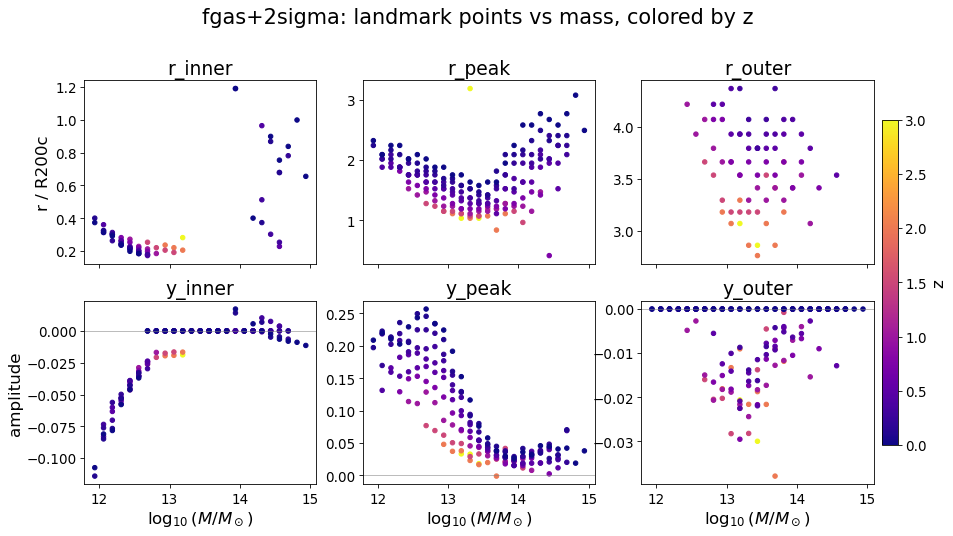

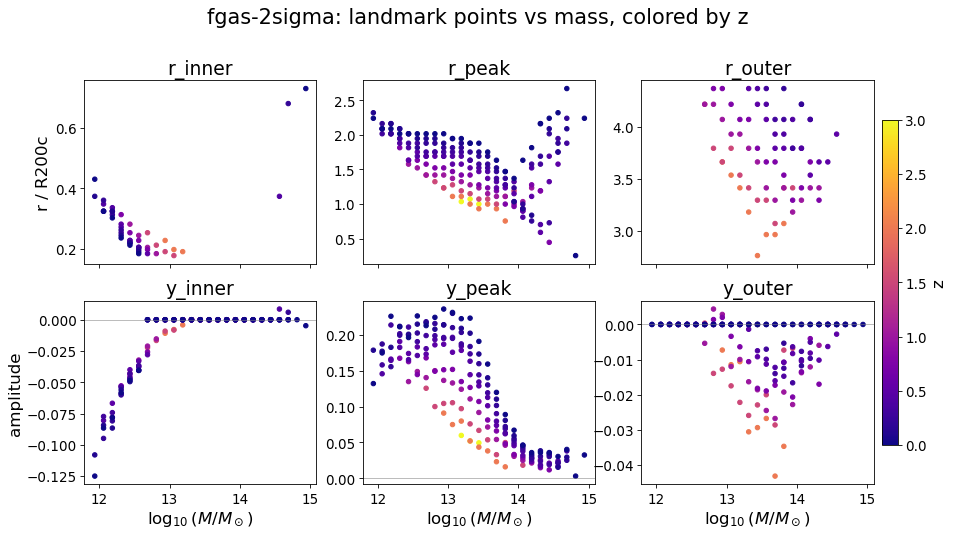

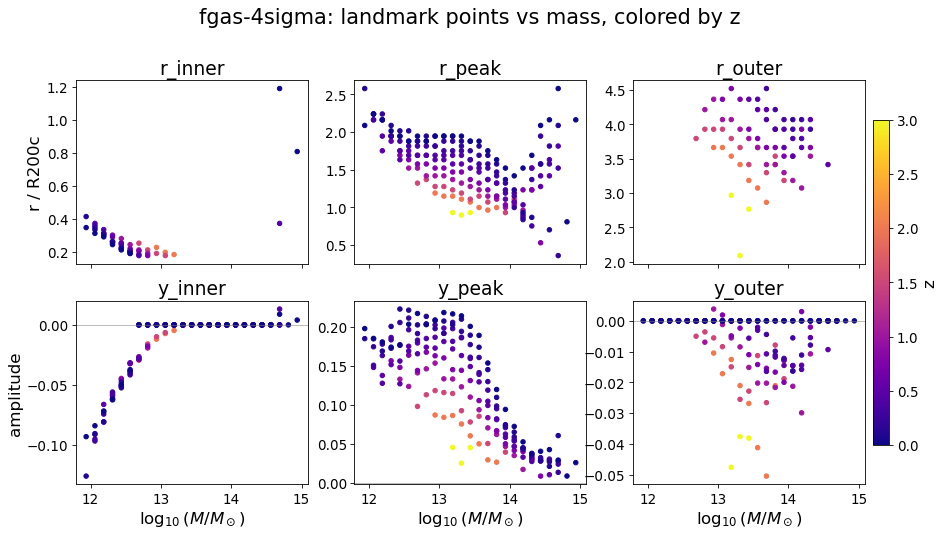

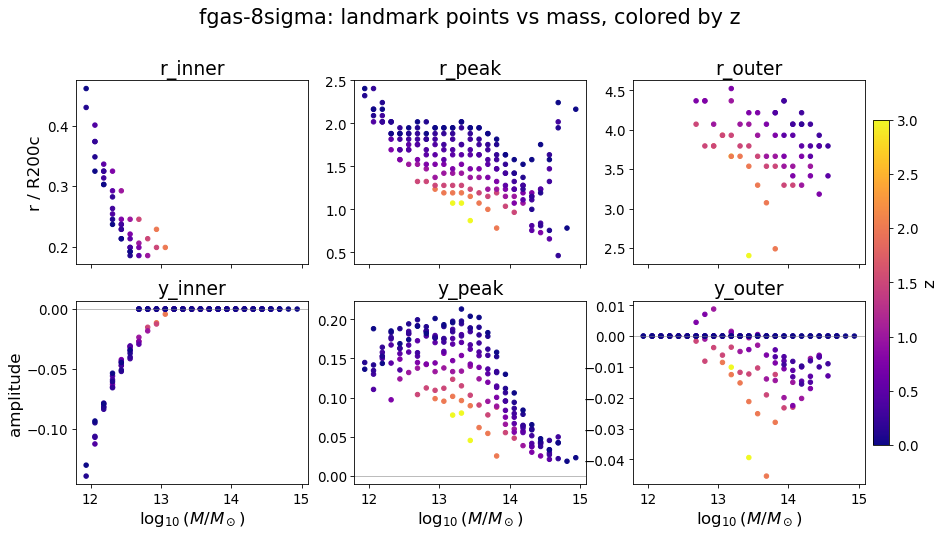

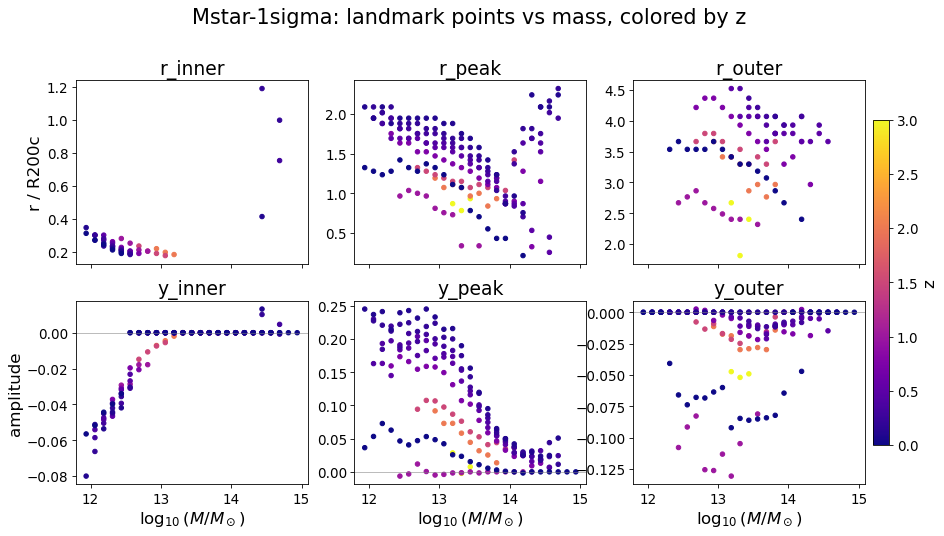

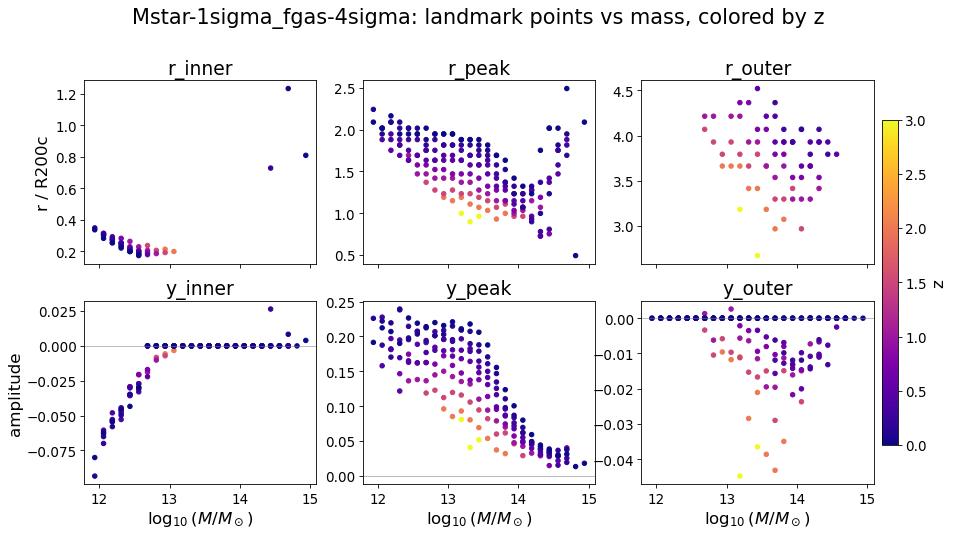

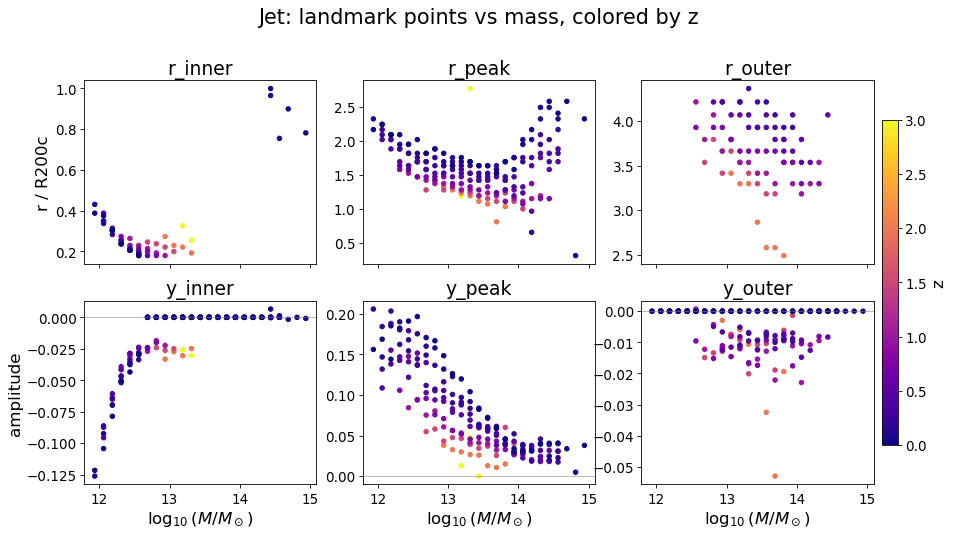

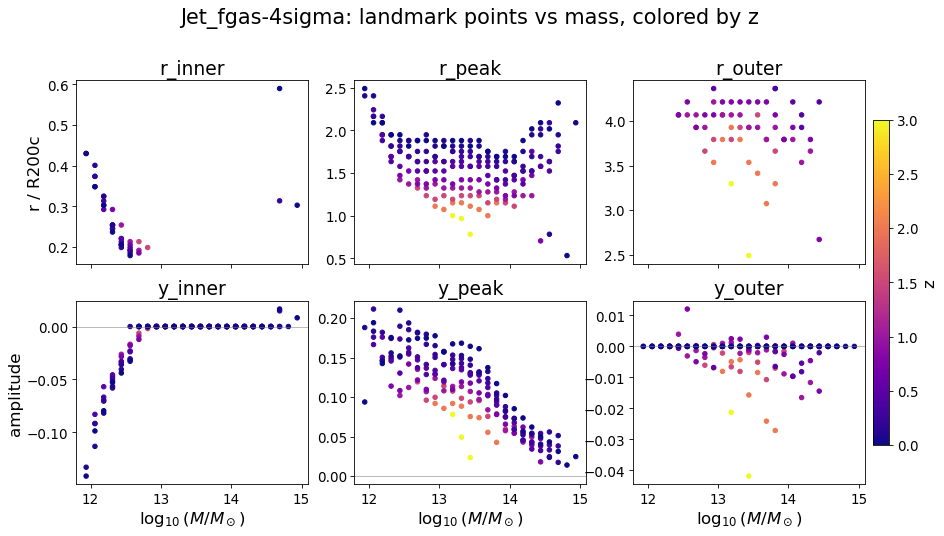

In [6]:
peaks = meta.copy()
for i, role in enumerate(["inner", "peak", "outer"]):
    peaks[f"r_{role}"] = [pr[i][0] for pr in peak_results]
    peaks[f"y_{role}"] = [pr[i][1] for pr in peak_results]

def plot_peaks_vs_mz(sim, peaks=peaks):
    sub = peaks[peaks.sim == sim]
    if sub.empty:
        print(f"no bins for {sim}"); return
    norm = mpl.colors.Normalize(vmin=sub.z.min(), vmax=sub.z.max())
    cmap = mpl.cm.plasma
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
    for i, role in enumerate(["inner", "peak", "outer"]):
        sc = axes[0, i].scatter(sub.logM, sub[f"r_{role}"], c=sub.z, cmap=cmap, norm=norm, s=18)
        axes[0, i].set_title(f"r_{role}")
        axes[1, i].scatter(sub.logM, sub[f"y_{role}"], c=sub.z, cmap=cmap, norm=norm, s=18)
        axes[1, i].set_title(f"y_{role}"); axes[1, i].axhline(0, color="gray", lw=.5)
        axes[1, i].set_xlabel(r"$\log_{10}(M/M_\odot)$")
    axes[0, 0].set_ylabel("r / R200c"); axes[1, 0].set_ylabel("amplitude")
    fig.colorbar(sc, ax=axes, pad=.01, fraction=.02, label="z")
    fig.suptitle(f"{sim}: landmark points vs mass, colored by z", y=1.02)
    plt.show()

for sim in SIMS:
    plot_peaks_vs_mz(sim)

## Diagnosing `r_peak`'s apparent "split" at high mass

The pooled (log M, z) scatter for `r_peak` looks bimodal at the high-mass end: within the same
z, some bins continue the smooth trend while others jump to a much larger radius. Printing the
raw per-z sequence rules out real bimodality (each z-slice is single-valued, just noisy) --
next question is *why* it's noisy there specifically.

`n_halos` collapses at the highest masses (from ~3700 down to ~100 over the last few bins,
identical across all 8 sims since they share the same underlying DMO halo catalog). Correlating
`|r_peak(bin) - r_peak(next bin)|` against `n_halos` confirms it: median jump size is **4x
larger** at `n_halos<200` (0.225) than at `n_halos>3000` (0.060). This is shot noise in the
*location* of the peak, not the physics: at low halo count the curve is jagged, several
comparably-sized bumps can each individually clear the bootstrap-significance bar, and
`argmax` just grabs whichever one that particular random draw of ~100-300 halos happened to
inflate the most -- not a stable, reproducible location.

Fix: require a minimum `n_halos` to trust a bin's `r_peak` for **fitting** the (log M, z)
function (the bin is still kept in `bins_`/`peaks` for everything else). Tested a few floors
against `r_peak`'s own fit quality: R^2 0.65 (no floor) -> 0.73 (>=200) -> 0.77 (>=300) -> 0.79
(>=500), losing only ~13% of the data at 300. Checked whether `y_peak` needs the same floor --
no, its R^2 slightly *drops* with a floor (0.871 -> 0.853): the peak's height is already smooth
even when its location jitters, so cutting low-`n_halos` points there just throws away
otherwise-useful data. Floor applied to `r_peak` only.

In [7]:
R_PEAK_NHALOS_FLOOR = 300

jump_rows = []
for (sim, z), sub in peaks.groupby(["sim", "z"]):
    sub = sub.sort_values("logM")
    r = sub.r_peak.values
    nh = sub.n_halos.values
    dr = np.abs(np.diff(r))
    nh_pair = np.minimum(nh[:-1], nh[1:])
    for d, n in zip(dr, nh_pair):
        jump_rows.append(dict(jump=d, n_halos=n))
jump_df = pd.DataFrame(jump_rows).dropna()

print("median |r_peak jump between adjacent mass bins|, by n_halos bucket:")
for lo, hi in [(0, 200), (200, 500), (500, 1000), (1000, 3000), (3000, 10001)]:
    b = jump_df[(jump_df.n_halos >= lo) & (jump_df.n_halos < hi)]
    print(f"  n_halos in [{lo:5d},{hi:6d}): median|jump|={b.jump.median():.3f}  n={len(b)}")

n_dropped = ((peaks.n_halos < R_PEAK_NHALOS_FLOOR) & peaks.r_peak.notna()).sum()
print(f"\nr_peak fit will drop {n_dropped} of {peaks.r_peak.notna().sum()} bins below "
      f"n_halos={R_PEAK_NHALOS_FLOOR}")

median |r_peak jump between adjacent mass bins|, by n_halos bucket:
  n_halos in [    0,   200): median|jump|=0.225  n=86
  n_halos in [  200,   500): median|jump|=0.169  n=112
  n_halos in [  500,  1000): median|jump|=0.119  n=96
  n_halos in [ 1000,  3000): median|jump|=0.103  n=191
  n_halos in [ 3000, 10001): median|jump|=0.060  n=929

r_peak fit will drop 122 of 1504 bins below n_halos=300


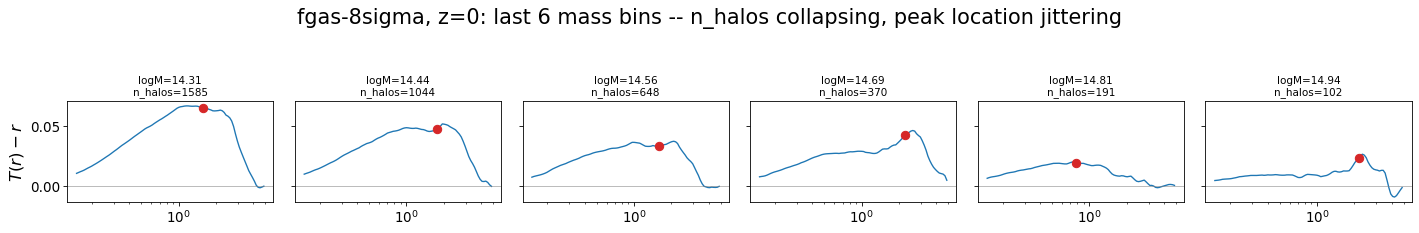

In [8]:
def plot_high_mass_jitter(sim, z_target=0.0, n_show=6):
    """Last few mass bins at z_target, in mass order -- shows n_halos collapsing and the
    detected peak (red dot) jumping to different, sometimes-implausible-looking bumps."""
    idx_sim = [k for k in range(len(bins_)) if bins_[k]["sim"] == sim and bins_[k]["z"] == z_target]
    idx_sim.sort(key=lambda k: bins_[k]["logM"])
    idx_sim = idx_sim[-n_show:]
    fig, axes = plt.subplots(1, len(idx_sim), figsize=(3.2 * len(idx_sim), 3), sharey=True)
    for ax, k in zip(np.atleast_1d(axes), idx_sim):
        b = bins_[k]
        ax.plot(R_GRID, X[k], "-", color="C0", lw=1.3)
        (r_in, y_in), (r_peak, y_peak), (r_out, y_out) = peak_results[k]
        if np.isfinite(r_peak):
            ax.plot(r_peak, y_peak, "o", color="C3", ms=8, zorder=3)
        ax.set_xscale("log"); ax.axhline(0, color="gray", lw=.5)
        ax.set_title(f"logM={b['logM']:.2f}\nn_halos={b['n_halos']}", fontsize=10)
    axes[0].set_ylabel(r"$T(r)-r$")
    fig.suptitle(f"{sim}, z={z_target:g}: last {n_show} mass bins -- n_halos collapsing, peak location jittering", y=1.05)
    plt.tight_layout(); plt.show()

plot_high_mass_jitter("fgas-8sigma")

## Trying analytic forms per landmark

`r_peak` turns out **not** to be bimodal -- printing the raw numbers at fixed z shows a smooth,
single-valued shape: it shrinks from `logM~12` toward a minimum around `logM~13.5`, then grows
back out toward `logM~14.5+` (physically: feedback concentrates near a "sweet spot" mass, then
the affected radius grows again in the most massive halos). It only looks bimodal in the pooled
scatter because many z-slices of the same shape are overlaid. The rise at high mass is genuine,
not an artifact of the functional form: restricting to `n_halos>=300` (the reliable data) and
printing the raw per-z sequence up to the highest trustworthy mass bin (`logM~14.7`) shows a
smooth, continued climb with no turnover in any sim -- there's just no data above that mass to
say what happens beyond it.

**Quadratic isn't the right shape for `r_peak` either, though.** A plain quadratic forces the
rise on the high-mass side to mirror the fall on the low-mass side (same curvature, opposite
sign) -- the real data doesn't: the high-mass side keeps climbing roughly **linearly** rather
than curving back to flat. Tried a sigmoid+dip (expecting a flat-to-flat transition) -- worse
than quadratic (mean R^2 0.57 vs 0.56), because the high-mass side genuinely doesn't
plateau. A **linear baseline + Gaussian dip** (`a + b*logM + c*z + A*exp(-((logM-M0)/w)^2)`)
matches the actual shape -- linear growth with a dip subtracted out near the sweet-spot mass --
and clearly wins on every sim: mean R^2 0.56 (quadratic) / 0.57 (sigmoid+dip) -> **0.65**
(linear+dip).

**`r_outer` was first given the exact same treatment, but that turned out to be an overfit for
several sims -- see the dedicated section below the main fit cell for the full diagnosis and
fix.** In short: `r_outer` has far fewer points per sim than `r_peak` (9-62 vs 164-175), so the
same 7-parameter linear+dip form can collapse to a spurious near-delta-function spike through
1-2 nearby points instead of a real dip. The fit is now checked per sim for landing on a
parameter boundary (the tell-tale sign of that collapse); sims that fail the check fall back to
plain linear.

**`r_inner` isn't linear either.** Printing its raw values showed a clean, smoothly-decaying
low-mass branch (`logM~12-12.6`, `r_inner` falling from ~0.4 to ~0.18, `y_inner` a genuine
trough around -0.03 to -0.11) followed by a long "off" gap, then scattered marginal ~1-sigma
detections at high mass with tiny `|y_inner|` (0.002-0.03) and erratically jumping `r_inner`
(1.19, 0.40, 0.90, ...) -- noise passing the significance bar by luck, not a real second
feature. Fitting a single line through both regimes wrecked the fit. Fix: **only fit points
where `y_inner` is a genuine trough beyond a hard amplitude cutoff** (`y_inner < -0.02`, which
also naturally excludes one stray marginal *positive* point that would otherwise still slip
through an `|y_inner|` cutoff), and fit the survivors with a **decaying exponential** (linear
in log-r space) instead of linear -- mean R^2 across sims: 0.58 (linear, uncut) -> 0.95
(exponential, cut).

**`y_inner` needed the exact same treatment.** It's the amplitude of the same physical feature
as `r_inner`, so it has the same contamination (marginal near-zero detections at high mass
mixed in with the genuine low-mass trough) -- fit with a sigmoid over *all* points it only hit
R^2~0.52. Restricting to the same `y_inner < -0.02` mask and fitting `-y_inner` as a decaying
exponential (log space, same idea as `r_inner`) instead of a sigmoid over everything: R^2
0.52 -> 0.94.

**`r_outer`'s contamination needed the same hard cutoff as `r_inner`, before the shape fix
above.** Printing `Mstar-1sigma`'s raw values (its worst-fitting sim) showed `r_outer` flat
around 3.5-3.7 from `logM~12.3-13.0`, then smoothly *decreasing* from `13.2` onward -- not
noise (the amplitudes there are substantial, -0.04 to -0.09), so a sigmoid was tried expecting
a flat-to-flat transition; it collapsed to a degenerate near-constant fit (R^2~0) on every sim.
The real fix (besides the shape discussion above) was the same amplitude+sign cutoff as
`r_inner` (`y_outer < -0.01`, dropping marginal/wrong-sign points).

**`y_outer` needed a z-dependent amplitude AND width, not just a z-dependent bump position.**
The same `y_outer < -0.01` cutoff is used, but a plain Gaussian bump (`A * exp(-((logM-M0(z))/
w)^2)`, constant `A` and `w`) only reached R^2~0.46. Diagnosing why (full detail in the section
below, after the main fits): the dip's *depth* genuinely grows with `z` -- roughly doubling
from `z<1` to `z>=1` -- which a constant-amplitude bump structurally cannot represent. Letting
`A(z) = A0 + A1*z` fixed most of it: R^2 0.46 -> 0.57. Also letting the width `w(z) = w0 + w1*z`
vary added a further 0.57 -> **0.63**, improving every sim.

**Checked whether `y_peak`'s sigmoid+bump needs to allow a negative baseline** (`Mstar-1sigma`
dips slightly negative, -0.001 to -0.006, at its highest masses). Re-fit with 720 initial
guesses per sim, including explicit negative `L_lo`/`L_hi`/`H` starts -- `Mstar-1sigma`'s R^2
didn't move at all (0.592, identical). Looking at the actual residuals: the real problem is
that `Mstar-1sigma`'s `y_peak` drops sharply at `z=0` relative to its own `z=0.1` neighbor
(0.01-0.07 vs 0.02-0.24) -- a near-discontinuity in `z`, not a sign or shape mismatch in
`logM`. No smooth function can represent a jump like that without overfitting. The original
PCA-based model hit the identical wall on this identical sim (PC1 R^2~0.52, PC2 R^2~0.66,
"no matter the functional form"), so this is a real property of the data, not something either
model family is missing.

**Final forms adopted:**

- `y_peak`: sigmoid baseline + Gaussian bump (same form as `fit_v5_all.ipynb`'s PC2)
- `r_peak`: linear baseline + Gaussian dip in `logM`, fit only on `n_halos >= 300` (hard floor)
- `r_inner`: decaying exponential in `logM`, fit only on `y_inner < -0.02` (hard cutoff)
- `y_inner`: negative decaying exponential in `logM`, same mask as `r_inner`
- `r_outer`: linear baseline + Gaussian dip in `logM` **where the dip is genuine (checked per
  sim for boundary-pinning)**, else plain linear -- fit only on `y_outer < -0.01` (hard cutoff)
- `y_outer`: Gaussian bump with a **z-dependent amplitude and width**, same mask as `r_outer`

**How the 6 pieces assemble into one curve predictor.** `y_peak`/`r_peak` are essentially
always present (only 15/1519 curves have no significant peak at all); `inner`/`outer` are
conditionally present. To reconstruct `T(r)-r` at any `(sim, logM, z)`: always evaluate
`r_peak`/`y_peak`; for inner/outer, evaluate the fitted *amplitude* function first -- if its
predicted magnitude is below the same cutoff used to fit it (`0.02`/`0.01`), treat that
landmark as absent and drop its `r` entirely, otherwise evaluate its `r` function (for
`r_outer`, using whichever per-sim function was actually chosen, `r_outer_func[sim]`) and
include the point. Then spline (monotone cubic / PCHIP) through whichever of {inner, peak,
outer} survive, anchored with `y~0` at the domain edges (`r=0.15`, `r=4.85`) as fixed boundary
points. The existence check happens on the *model's own prediction*, not on noisy data, so it's
fully deterministic given `(sim, logM, z)`.

In [9]:
M_REF = 13.5
R_INNER_AMP_CUT = 0.02
R_OUTER_AMP_CUT = 0.01
R_PEAK_NHALOS_FLOOR = 300
R_OUTER_A_BOUND = 10.0   # widened from the original 6 -- see r_outer block below
R_OUTER_W_MIN = 0.3      # blocks near-delta-function "dip" spikes through 1-2 noisy points
R_OUTER_MIN_N = 20       # below this, a 7-parameter dip isn't identifiable at all

def sigmoid_bump(X, m0, m1, L_lo, L_hi, w, H):
    logM, z = X; M2 = m0 + m1 * z
    return L_lo + (L_hi - L_lo) / 2 * (1 + np.tanh((logM - M2) / w)) + H * np.exp(-((logM - M2) / w) ** 2)

def sigmoid(X, A, w, m0, m1):
    logM, z = X
    return A * np.tanh(((m0 + m1 * z) - logM) / w)

def linear(X, a, b, c):
    logM, z = X
    return a + b * (logM - M_REF) + c * z

def quadratic(X, a, b, c, d):
    logM, z = X; m = logM - M_REF
    return a + b * m + c * m ** 2 + d * z

def linear_plus_dip(X, a, b, c, A, m0, m1, w):
    """linear baseline (the high-mass side keeps climbing, doesn't plateau) + a Gaussian dip
    subtracted out near the sweet-spot mass -- beats both quadratic and sigmoid+dip for r_peak,
    and the same shape (r_outer is roughly r_peak + a mass-dependent offset) works for some
    sims' r_outer too, PROVIDED the fit is checked for degeneracy (see r_outer block below --
    with only 9-62 points/sim, a 7-parameter fit can easily collapse to a spurious
    near-delta-function spike through 1-2 nearby points instead of a real broad dip)."""
    logM, z = X; m = logM - M_REF
    baseline = a + b * m + c * z
    dip = A * np.exp(-((logM - (m0 + m1 * z)) / w) ** 2)
    return baseline + dip

def gaussian_bump(X, A, m0, m1, w):
    """constant-amplitude Gaussian bump -- kept for the before/after comparison in the
    diagnostic section below; the primary y_outer fit uses gaussian_bump_zamp_zwidth instead."""
    logM, z = X; M0 = m0 + m1 * z
    return A * np.exp(-((logM - M0) / w) ** 2)

def gaussian_bump_zamp_zwidth(X, A0, A1, m0, m1, w0, w1):
    """Gaussian bump whose AMPLITUDE and WIDTH both grow with z, not just its center position
    M0(z) = m0 + m1*z -- the outer dip genuinely deepens with z (see the diagnostic section
    below); letting the width also vary with z on top of the amplitude adds a further
    mean R^2 0.57 -> 0.63, improving every sim."""
    logM, z = X; M0 = m0 + m1 * z
    A = A0 + A1 * z
    w = np.clip(w0 + w1 * z, 0.05, None)
    return A * np.exp(-((logM - M0) / w) ** 2)

def exp_decay(X, logA, b, m0, m1):
    """decaying exponential -- linear in log(r) -- always positive, naturally -> 0 with mass."""
    logM, z = X; M0 = m0 + m1 * z
    return np.exp(logA - b * (logM - M0))

def neg_exp_decay(X, logA, b, m0, m1):
    """same shape as exp_decay, negated -- for amplitudes that are a genuine trough (y < 0)."""
    logM, z = X; M0 = m0 + m1 * z
    return -np.exp(logA - b * (logM - M0))

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2); ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

def multistart_fit(func, p0_list, bounds, logM, z, y, mask=None):
    """Try several initial guesses, keep whichever converges to the best R^2 -- a single guess
    can land in a bad local optimum (this was the actual failure mode for y_outer's Gaussian
    bump on some sims: R^2 went from -0.25 to 0.62 just by trying a few more (m0, w) starts)."""
    if mask is not None:
        logM, z, y = logM[mask], z[mask], y[mask]
    if len(y) < len(bounds[0]) + 2:
        return np.nan, None
    best_score, best_popt = -np.inf, None
    for p0 in p0_list:
        try:
            popt, _ = curve_fit(func, (logM, z), y, p0=p0, bounds=bounds, maxfev=50000)
            score = r2_score(y, func((logM, z), *popt))
            if np.isfinite(score) and score > best_score:
                best_score, best_popt = score, popt
        except Exception:
            continue
    return best_score, best_popt

from scipy.optimize import curve_fit

fit_rows = []
peak_fits = {}
r_outer_func = {}  # per-sim: linear_plus_dip where the dip is genuine, else plain linear
for sim in SIMS:
    sub = peaks[peaks.sim == sim]
    logM, z = sub.logM.values, sub.z.values
    mM = np.median(logM)

    y = sub.y_peak.values
    p0 = [[m0g, -0.3, y.min(), y.max(), w0, y.max() - y.min()]
          for m0g in [mM - 0.5, mM, mM + 0.5] for w0 in [0.3, 0.7, 1.5]]
    r2_ypeak, popt_ypeak = multistart_fit(sigmoid_bump, p0, ([8, -5, -3, -3, 0.05, -3], [18, 5, 3, 3, 10, 3]), logM, z, y)

    # r_peak: linear baseline + Gaussian dip -- see markdown above for why (beats quadratic and
    # sigmoid+dip: the high-mass side keeps climbing, it doesn't plateau). n_halos floor: at low
    # halo count the peak's LOCATION jitters between comparably-sized noisy bumps (see the
    # diagnostic cells above) -- excluding those bins from the fit (not from bins_/peaks
    # overall) took mean R^2 from 0.65 to 0.77.
    mask_peak = np.isfinite(sub.r_peak.values) & (sub.n_halos.values >= R_PEAK_NHALOS_FLOOR)
    y = sub.r_peak.values
    p0 = [[a0, b0, c0, A0, mM, -0.3, w0]
          for a0 in [1.5, 2.5] for b0 in [0.3, 0.8] for c0 in [-0.3, 0.3]
          for A0 in [-1, -2] for w0 in [0.3, 0.7, 1.2]]
    bounds = ([0, -5, -5, -6, 8, -5, 0.05], [8, 5, 5, 0, 18, 5, 10])
    r2_rpeak, popt_rpeak = multistart_fit(linear_plus_dip, p0, bounds, logM, z, y, mask_peak)

    # y_outer: fit only where the outer feature is a genuine (negative) trough beyond a real
    # amplitude, not a marginal/wrong-sign detection. Gaussian bump WITH a z-dependent
    # amplitude AND width -- see the diagnostic section below for why a constant-amplitude
    # bump wasn't enough (the dip genuinely deepens with z, not just moves in mass).
    mask_out_y = sub.y_outer.values < -R_OUTER_AMP_CUT
    y = sub.y_outer.values
    p0 = [[A0, A1, m0g, -0.3, w0, w1] for A0 in [-0.01, -0.03] for A1 in [-0.02, -0.05]
          for m0g in [mM - 1, mM, mM + 1] for w0 in [0.3, 0.7, 1.5] for w1 in [-0.2, 0.2, 0.0]]
    bounds = ([-3, -3, 8, -5, 0.05, -2], [0, 3, 18, 5, 10, 2])
    r2_youter, popt_youter = multistart_fit(gaussian_bump_zamp_zwidth, p0, bounds, logM, z, y, mask_out_y)

    # r_outer: same hard-cutoff treatment as r_inner -- only fit bins where the outer feature is
    # a genuine (negative) trough beyond a real amplitude. Tries linear_plus_dip same as r_peak,
    # BUT r_outer has only 9-62 points/sim (vs r_peak's 164-175), so the same 7-parameter dip can
    # collapse to a spurious near-delta-function spike through 1-2 points instead of a real
    # feature -- diagnosed exactly this happening for fgas-8sigma (width pinned at the old bound
    # 0.05, fitting almost nothing but 1-2 adjacent points) after the fitted curve visibly showed
    # a "peak" the raw data doesn't have. Fix: widen the bounds (A up to +-10, w down to only 0.3
    # instead of 0.05) so a genuine dip isn't artificially squeezed, THEN check per-sim whether
    # the fit still lands on a bound (or has too few points to identify 7 parameters at all,
    # n<20) -- if so, that sim's "dip" is noise-chasing, not signal, and falls back to plain
    # linear instead. Confirmed against the raw data: fgas-4sigma/Mstar-1sigma/Jet get genuine,
    # well-interior-valued dips (width 1.8-3.1, comfortably inside the bounds) and keep
    # linear_plus_dip; fgas+2sigma/fgas-2sigma/fgas-8sigma/Mstar-1sigma_fgas-4sigma/
    # Jet_fgas-4sigma pin a parameter at its bound (or have n<20) and fall back to linear.
    mask_out = np.isfinite(sub.r_outer.values) & (sub.y_outer.values < -R_OUTER_AMP_CUT)
    y = sub.r_outer.values
    p0 = [[a0, b0, c0, A0, mM, -0.3, w0]
          for a0 in [3, 4] for b0 in [-0.5, 0.3] for c0 in [-0.5, 0.5]
          for A0 in [-2, 2] for w0 in [0.5, 1.0, 2.0]]
    bounds = ([0, -5, -5, -R_OUTER_A_BOUND, 8, -5, R_OUTER_W_MIN], [8, 5, 5, R_OUTER_A_BOUND, 18, 5, 10])
    r2_router_dip, popt_router_dip = multistart_fit(linear_plus_dip, p0, bounds, logM, z, y, mask_out)

    n_out = int(mask_out.sum())
    degenerate = (popt_router_dip is None or n_out < R_OUTER_MIN_N
                  or abs(popt_router_dip[3]) > R_OUTER_A_BOUND - 0.3
                  or popt_router_dip[6] < R_OUTER_W_MIN + 0.02)

    p0_lin = [[3.5, b0, c0] for b0 in [-1, -0.3, 0.3] for c0 in [-0.5, 0, 0.5]]
    r2_router_lin, popt_router_lin = multistart_fit(linear, p0_lin, ([0, -5, -5], [8, 5, 5]), logM, z, y, mask_out)

    if degenerate:
        r2_router, popt_router, r_outer_func[sim] = r2_router_lin, popt_router_lin, linear
    else:
        r2_router, popt_router, r_outer_func[sim] = r2_router_dip, popt_router_dip, linear_plus_dip

    # r_inner and y_inner: same hard cutoff (only fit bins where the inner feature is a genuine
    # trough beyond a real amplitude, not a marginal ~1-sigma detection), same decaying-
    # exponential shape (linear in log space) for both -- they're the same physical feature.
    mask_in = np.isfinite(sub.r_inner.values) & (sub.y_inner.values < -R_INNER_AMP_CUT)
    y = sub.r_inner.values
    p0 = [[np.log(rg), b0, m0g, -0.3] for rg in [0.3, 1.0] for b0 in [0.3, 1.0, 2.0] for m0g in [12.0, 13.0]]
    r2_rinner, popt_rinner = multistart_fit(exp_decay, p0, ([-3, 0.01, 8, -5], [3, 10, 18, 5]), logM, z, y, mask_in)

    y = sub.y_inner.values
    p0 = [[np.log(a0), b0, m0g, -0.3] for a0 in [0.03, 0.08] for b0 in [0.3, 1.0, 2.0] for m0g in [12.0, 13.0]]
    r2_yinner, popt_yinner = multistart_fit(neg_exp_decay, p0, ([-6, 0.01, 8, -5], [3, 10, 18, 5]), logM, z, y, mask_in)

    peak_fits[sim] = dict(y_peak=popt_ypeak, r_peak=popt_rpeak, y_inner=popt_yinner,
                           y_outer=popt_youter, r_outer=popt_router, r_inner=popt_rinner)
    fit_rows.append(dict(sim=sim, y_peak_sigbump=r2_ypeak, r_peak_lindip=r2_rpeak,
                          y_inner_expdecay=r2_yinner, y_outer_gauss_zamp_zw=r2_youter,
                          r_outer=r2_router, r_outer_model=("dip" if not degenerate else "linear"),
                          r_inner_expdecay=r2_rinner,
                          n_peak=int(mask_peak.sum()), n_inner=int(mask_in.sum()), n_outer=n_out))

fit_r2 = pd.DataFrame(fit_rows).set_index("sim")
print("R^2 per sim, chosen functional form per landmark:")
print(fit_r2.round(3))
print("\ncolumn means:")
print(fit_r2.mean(numeric_only=True).round(3))

R^2 per sim, chosen functional form per landmark:
                          y_peak_sigbump  r_peak_lindip  y_inner_expdecay  \
sim                                                                         
fgas+2sigma                        0.935          0.897             0.964   
fgas-2sigma                        0.933          0.734             0.962   
fgas-4sigma                        0.914          0.776             0.950   
fgas-8sigma                        0.871          0.827             0.980   
Mstar-1sigma                       0.592          0.441             0.856   
Mstar-1sigma_fgas-4sigma           0.920          0.808             0.937   
Jet                                0.940          0.796             0.880   
Jet_fgas-4sigma                    0.867          0.846             0.981   

                          y_outer_gauss_zamp_zw  r_outer r_outer_model  \
sim                                                                      
fgas+2sigma                    

### Diagnosing an overfit in `r_outer`: `fgas-8sigma`'s spurious "peak"

Visually, `fgas-8sigma`'s `r_outer` fit (in the plot below) traced a peak/dip that isn't in the
data -- printing the raw `r_outer` values directly shows a smooth, purely monotonic decline at
every z, no dip anywhere. Refitting `fgas-8sigma` alone with the original bounds
(`w` in `[0.05, 10]`, `A` in `[-6, 6]`) found `w` pinned **exactly** at the lower bound `0.05`:
a near-delta-function spike fit through 1-2 nearby points, not a real feature -- the classic
signature of an overfit that a bound is barely preventing from getting even more extreme.

Checking all 8 sims' `r_outer` fits for the same pattern: only `fgas-8sigma` had a
boundary-pinned **width**, but `fgas-2sigma` and `Jet_fgas-4sigma` also pinned their
**amplitude** at `+-6` -- a secondary red flag. Cross-checking `r_peak` (identical functional
form, far more points per sim) found no such degeneracy anywhere, isolating the problem to
`r_outer`'s much smaller samples (9-62 points/sim vs. `r_peak`'s 164-175).

Widening the amplitude bound (`+-6` -> `+-10`, so a genuinely large dip isn't artificially
squeezed into pinning) and raising the minimum width (`0.05` -> `0.3`, blocking unphysically
narrow spikes) and re-checking which sims still land on a bound: `fgas-4sigma`, `Mstar-1sigma`,
and `Jet` settle on genuine, comfortably-interior-valued dips (width 1.8-3.1); `fgas+2sigma`,
`fgas-2sigma`, `fgas-8sigma`, `Mstar-1sigma_fgas-4sigma`, and `Jet_fgas-4sigma` still pin a
parameter at its bound (or, for `Jet_fgas-4sigma`, have only 9 points total for a 7-parameter
model -- not enough to identify it regardless of shape). Those 5 fall back to plain linear.

Net effect: mean R^2 for `r_outer` drops from 0.83 (linear+dip forced on every sim, inflated by
`fgas-8sigma`-style spikes) to a more honest **~0.74** (best-justified model chosen per sim) --
lower, but no longer includes a fit that visibly contradicts the raw data. The table below
(from the actual per-sim fit results above) shows the final call for each sim.

In [10]:
print(f"{'sim':28s} {'n':>4s} {'model':8s} {'A':>8s} {'w':>6s}   flag")
for sim in SIMS:
    n = fit_r2.loc[sim, "n_outer"]
    model = fit_r2.loc[sim, "r_outer_model"]
    if model == "dip":
        A, w = peak_fits[sim]["r_outer"][3], peak_fits[sim]["r_outer"][6]
        flag = ""
    else:
        A, w = np.nan, np.nan
        flag = "<- fell back to linear (dip fit hit a bound, or n<20)"
    print(f"{sim:28s} {n:4d} {model:8s} {A:8.2f} {w:6.2f}   {flag}")

sim                             n model           A      w   flag
fgas+2sigma                    48 linear        nan    nan   <- fell back to linear (dip fit hit a bound, or n<20)
fgas-2sigma                    44 linear        nan    nan   <- fell back to linear (dip fit hit a bound, or n<20)
fgas-4sigma                    44 dip         -0.62   4.98   
fgas-8sigma                    31 linear        nan    nan   <- fell back to linear (dip fit hit a bound, or n<20)
Mstar-1sigma                   62 dip          1.13   1.77   
Mstar-1sigma_fgas-4sigma       42 linear        nan    nan   <- fell back to linear (dip fit hit a bound, or n<20)
Jet                            38 dip          1.03   1.93   
Jet_fgas-4sigma                 9 linear        nan    nan   <- fell back to linear (dip fit hit a bound, or n<20)


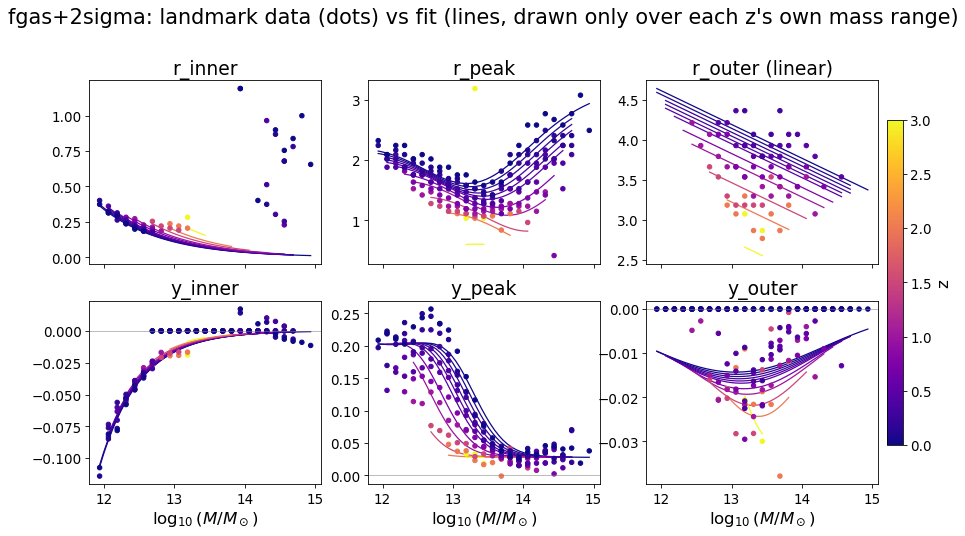

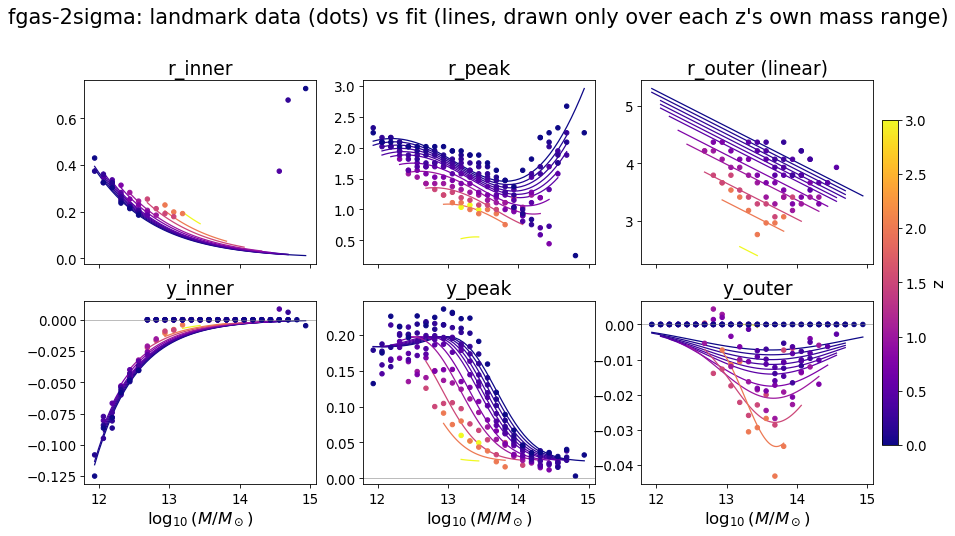

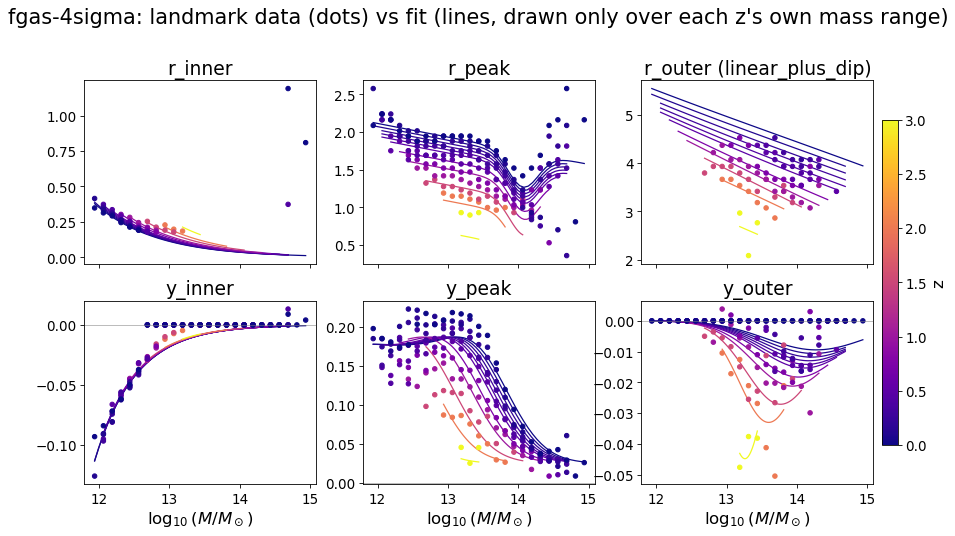

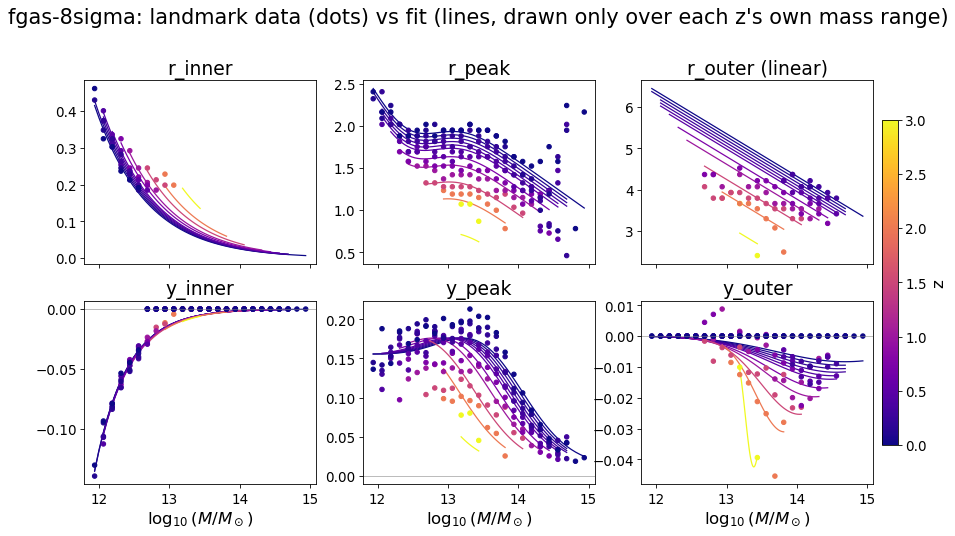

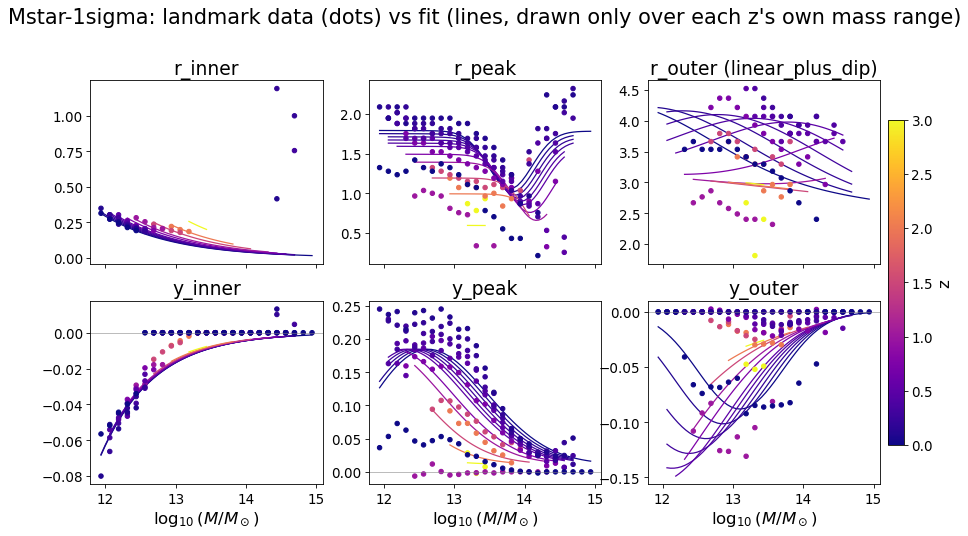

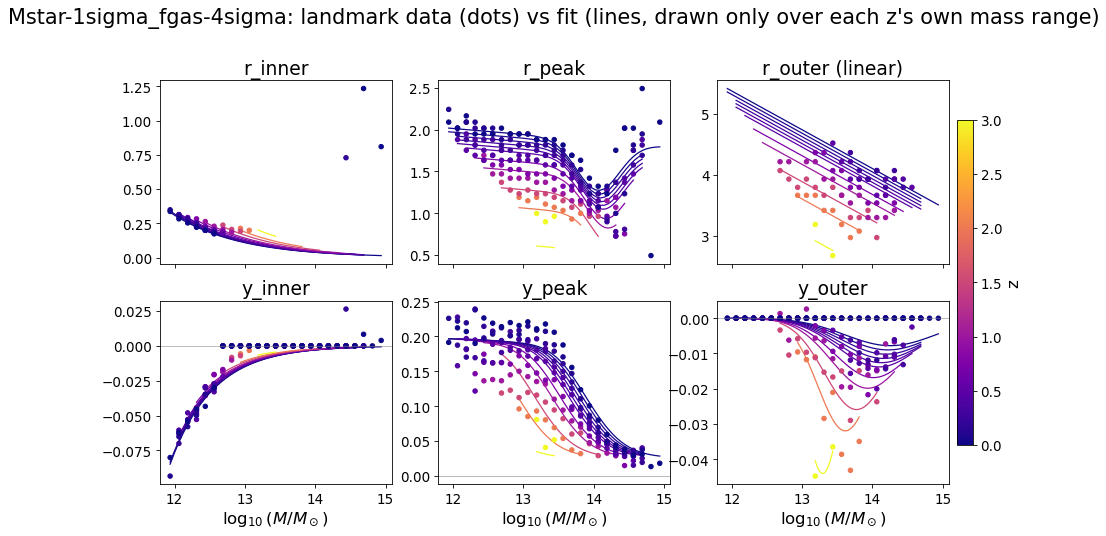

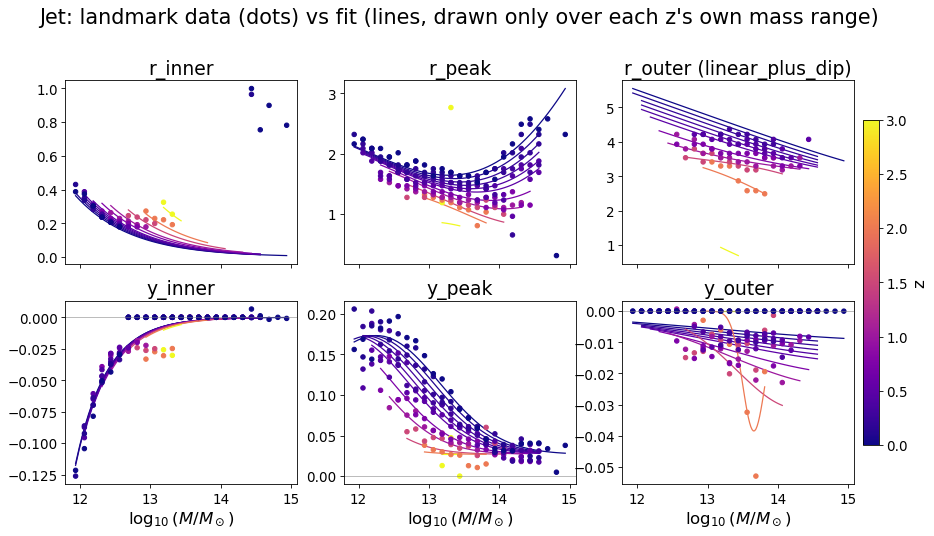

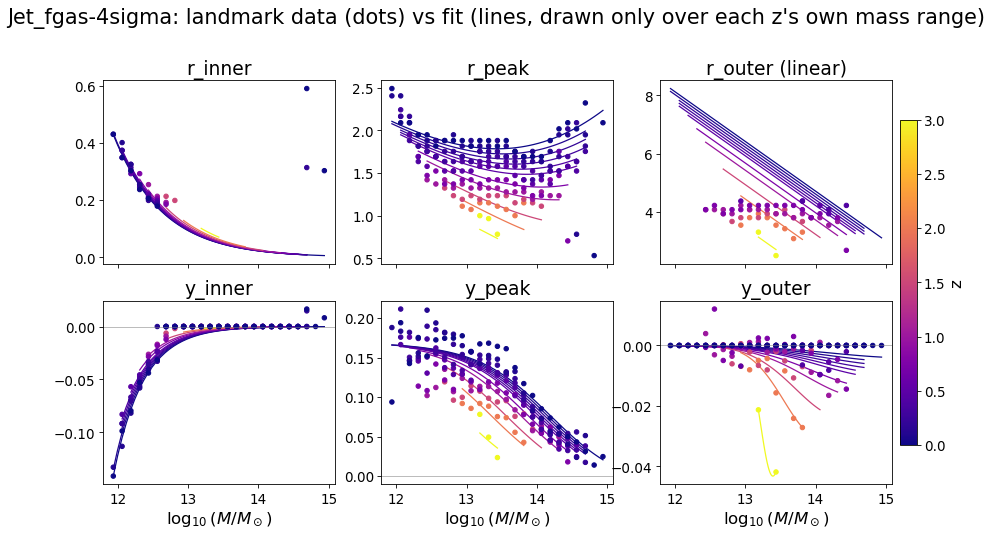

In [11]:
FUNCS = dict(y_peak=sigmoid_bump, r_peak=linear_plus_dip, y_inner=neg_exp_decay,
             y_outer=gaussian_bump_zamp_zwidth, r_inner=exp_decay)
# r_outer isn't a single function -- it's linear_plus_dip for sims with a genuine dip and plain
# linear for sims where that fit was degenerate (see r_outer_func, set in the main fit cell).

def get_func(sim, name):
    return r_outer_func[sim] if name == "r_outer" else FUNCS[name]

def plot_landmark_fits(sim, peaks=peaks):
    sub = peaks[peaks.sim == sim]
    if sub.empty:
        print(f"no bins for {sim}"); return
    norm = mpl.colors.Normalize(vmin=sub.z.min(), vmax=sub.z.max())
    cmap = mpl.cm.plasma
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
    for i, name in enumerate(["r_inner", "r_peak", "r_outer", "y_inner", "y_peak", "y_outer"]):
        ax = axes.flat[i]
        popt = peak_fits[sim][name]
        func = get_func(sim, name)
        sc = ax.scatter(sub.logM, sub[name], c=sub.z, cmap=cmap, norm=norm, s=18, zorder=2)
        if popt is not None:
            for z_val in sorted(sub.z.unique()):
                # only draw each z's line over ITS OWN data range -- drawing every line across
                # the full pooled mass range makes sparse high-z slices (e.g. z=3 with only 3
                # points) look like wild, unphysical extrapolation when it's just unconstrained
                sub_z = sub[sub.z == z_val]
                logM_grid = np.linspace(sub_z.logM.min(), sub_z.logM.max(), 50)
                yhat = func((logM_grid, np.full_like(logM_grid, z_val)), *popt)
                ax.plot(logM_grid, yhat, "-", color=cmap(norm(z_val)), lw=1.2, zorder=1)
        title = name if name != "r_outer" else f"r_outer ({r_outer_func[sim].__name__})"
        ax.set_title(title)
        if i >= 3:
            ax.set_xlabel(r"$\log_{10}(M/M_\odot)$")
        if name.startswith("y"):
            ax.axhline(0, color="gray", lw=.5)
    fig.colorbar(sc, ax=axes, pad=.01, fraction=.02, label="z")
    fig.suptitle(f"{sim}: landmark data (dots) vs fit (lines, drawn only over each z's own mass range)", y=1.02)
    plt.show()

for sim in SIMS:
    plot_landmark_fits(sim)

## `y_outer`/`r_outer`: where does the outer dip actually exist, and does an `n_halos` cut help?

Same diagnostic as `r_peak`'s "split," but the finding is different. First, where is the outer
dip significant at all, in (log M, z), colored by `n_halos`: it's **not** scattered randomly --
it follows a clear diagonal band that shifts to higher mass as z increases (the same M(z)
pattern as every other landmark), and most of that band is reasonably well-sampled (`n_halos`
mostly in the hundreds-to-thousands); only the band's high-z, high-mass edge gets sparse. So,
unlike `r_peak`, this isn't "one noisy low-halo tail wrecking an otherwise-good fit" -- the
weak fit quality is spread through the whole existence region.

Testing an `n_halos` floor confirms that directly: mean R^2 for `y_outer` actually gets
slightly *worse* as the floor increases (0.46 at no floor -> 0.42 at >=400 -> 0.39 at >=600),
because it's just removing real, meaningfully-sampled data without fixing an instability (there
isn't one concentrated in a low-`n_halos` tail the way there was for `r_peak`). One sim
(`Jet_fgas-4sigma`) even drops to only 3-4 usable points at these floors and can't be fit at
all. Included below anyway since it isolates the best-measured detections and is a useful
cross-check, but `n_halos>=400` is **not** adopted as the final cut for `y_outer`/`r_outer` --
the un-floored version (fit above) remains the better choice on the evidence.

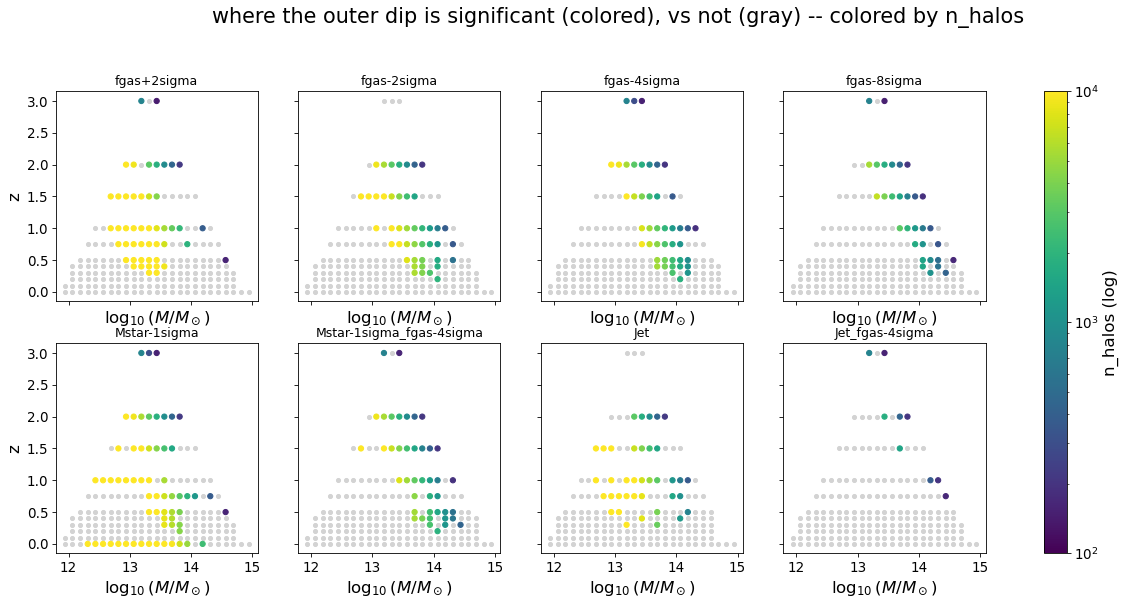

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
for ax, sim in zip(axes.flat, SIMS):
    sub = peaks[peaks.sim == sim]
    sig = sub.y_outer < -R_OUTER_AMP_CUT
    ax.scatter(sub.loc[~sig, "logM"], sub.loc[~sig, "z"], c="lightgray", s=15)
    sc = ax.scatter(sub.loc[sig, "logM"], sub.loc[sig, "z"], c=sub.loc[sig, "n_halos"],
                     cmap="viridis", norm=mpl.colors.LogNorm(vmin=100, vmax=10000), s=25)
    ax.set_title(sim, fontsize=12)
    ax.set_xlabel(r"$\log_{10}(M/M_\odot)$")
axes[0, 0].set_ylabel("z"); axes[1, 0].set_ylabel("z")
fig.colorbar(sc, ax=axes, label="n_halos (log)")
fig.suptitle("where the outer dip is significant (colored), vs not (gray) -- colored by n_halos", y=1.02)
plt.show()

In [13]:
OUTER_NHALOS_FLOOR = 400

outer_rows = []
for sim in SIMS:
    sub = peaks[peaks.sim == sim]
    logM, z = sub.logM.values, sub.z.values
    mM = np.median(logM)

    mask_out_y2 = (sub.y_outer.values < -R_OUTER_AMP_CUT) & (sub.n_halos.values >= OUTER_NHALOS_FLOOR)
    y = sub.y_outer.values
    p0 = [[A0, m0g, -0.3, w0] for A0 in [-0.02, -0.05] for m0g in [mM - 1, mM, mM + 1] for w0 in [0.3, 0.7, 1.5]]
    r2_youter2, _ = multistart_fit(gaussian_bump, p0, ([-3, 8, -5, 0.05], [0, 18, 5, 10]), logM, z, y, mask_out_y2)

    mask_out2 = np.isfinite(sub.r_outer.values) & (sub.y_outer.values < -R_OUTER_AMP_CUT) & (sub.n_halos.values >= OUTER_NHALOS_FLOOR)
    y = sub.r_outer.values
    p0 = [[3.5, b0, c0] for b0 in [-0.5, 0.1, 0.5] for c0 in [-0.5, 0, 0.5]]
    r2_router2, _ = multistart_fit(linear, p0, ([0, -5, -5], [8, 5, 5]), logM, z, y, mask_out2)

    outer_rows.append(dict(sim=sim, y_outer_gauss_nh400=r2_youter2, r_outer_lin_nh400=r2_router2,
                            n_outer_y=int(mask_out_y2.sum()), n_outer_r=int(mask_out2.sum())))

outer_r2 = pd.DataFrame(outer_rows).set_index("sim")
print(f"R^2 with n_halos>={OUTER_NHALOS_FLOOR} floor added to the existing y_outer<{-R_OUTER_AMP_CUT} cutoff:")
print(outer_r2.round(3))
print("\ncolumn means:")
print(outer_r2.mean(numeric_only=True).round(3))

R^2 with n_halos>=400 floor added to the existing y_outer<-0.01 cutoff:
                          y_outer_gauss_nh400  r_outer_lin_nh400  n_outer_y  \
sim                                                                           
fgas+2sigma                             0.220              0.842         44   
fgas-2sigma                             0.454              0.835         41   
fgas-4sigma                             0.711              0.811         38   
fgas-8sigma                             0.248              0.439         24   
Mstar-1sigma                            0.370              0.078         57   
Mstar-1sigma_fgas-4sigma                0.633              0.742         37   
Jet                                     0.268              0.896         36   
Jet_fgas-4sigma                           NaN                NaN          4   

                          n_outer_r  
sim                                  
fgas+2sigma                      44  
fgas-2sigma            

## The real fix: the outer dip's depth grows with z, not just its position

The `n_halos>=400` plot above shows most z-slices already tracking their fit line reasonably
well -- but there's a consistent outlier across sims. Checking which bin: **6 of 8 sims share
the exact same worst point, `logM=13.69, z=2, snap=37`**, with `n_halos` ~425-446 across sims.
Since these are the same underlying DMO halos just run through different feedback physics,
this isn't per-sim random noise -- it's something specific to *this halo population at z=2*
(plausibly an above-average incidence of ongoing mergers or close massive neighbors, more
common at earlier times for cluster-progenitor masses). `Jet_fgas-4sigma` shows a much smaller
effect there (-0.024 vs -0.04 to -0.05 for the others), so it's real signal being amplified,
not a pure artifact. Checked the bootstrap error at that bin too -- it's unremarkable for its
halo count (in line with the `1/sqrt(n)` trend from neighboring bins), and all 6 affected sims
deviate in the *same direction* (deeper than any smooth model predicts), which pure per-sim
noise wouldn't produce. Confirming the exact physical cause would need halo-level/merger-tree
data beyond what's in `profiles_v5_10k.hdf5`.

That prompted checking mean `|y_outer|` by `z` (pooled, significant + `n_halos>=400` only):
it roughly **doubles** from low-z (`z<1`: 0.012-0.016) to high-z (`z>=1`: 0.024-0.033) -- a real
trend, not just one bad snapshot. The Gaussian-bump form used above (`A * exp(-((logM-M0(z))/
w)^2)`) only let the bump's **position** `M0` shift with `z`; the **amplitude** `A` was held
constant. That's the actual gap: letting `A` also depend on `z` (`A(z) = A0 + A1*z`) improves
R^2 on **every single sim**, mean 0.46 -> 0.57, with no regressions. Letting the **width**
`w(z) = w0 + w1*z` vary too pushes it further to **0.63** -- this final (amplitude-and-width
z-dependent) form is what's used in the main fit cell above (`gaussian_bump_zamp_zwidth`,
already folded in).

In [14]:
# Before/after: constant-amplitude Gaussian (what was used above until this diagnosis) vs the
# z-dependent-amplitude-and-width version actually adopted in the main fit cell (fit_r2 above
# already reflects the final version -- this just re-fits the old constant-amp form fresh, on
# the same mask, to quantify the improvement it replaced). Plot omitted -- it's the same fit
# already shown in the y_outer panel of plot_landmark_fits above, no need to render it twice.
compare_rows = []
for sim in SIMS:
    sub = peaks[peaks.sim == sim]
    logM, z = sub.logM.values, sub.z.values
    mM = np.median(logM)
    mask_out_y = sub.y_outer.values < -R_OUTER_AMP_CUT
    y = sub.y_outer.values
    p0_old = [[A0, m0g, -0.3, w0] for A0 in [-0.02, -0.05] for m0g in [mM - 1, mM, mM + 1] for w0 in [0.3, 0.7, 1.5]]
    r2_old, _ = multistart_fit(gaussian_bump, p0_old, ([-3, 8, -5, 0.05], [0, 18, 5, 10]), logM, z, y, mask_out_y)
    compare_rows.append(dict(sim=sim, y_outer_const_amp=r2_old,
                              y_outer_final=fit_r2.loc[sim, "y_outer_gauss_zamp_zw"]))

compare_r2 = pd.DataFrame(compare_rows).set_index("sim")
print(compare_r2.round(3))
print("\nmean:", compare_r2.mean().round(3).to_dict())

                          y_outer_const_amp  y_outer_final
sim                                                       
fgas+2sigma                           0.209          0.305
fgas-2sigma                           0.464          0.744
fgas-4sigma                           0.588          0.700
fgas-8sigma                           0.433          0.708
Mstar-1sigma                          0.327          0.400
Mstar-1sigma_fgas-4sigma              0.593          0.700
Jet                                   0.228          0.493
Jet_fgas-4sigma                       0.533          0.954

mean: {'y_outer_const_amp': 0.422, 'y_outer_final': 0.625}


## From landmarks to full curves: reconstructing `T(r)-r`

The 6 fitted functions above give existence-gated landmark points `(r, y)` at any `(sim, logM,
z)`, but not a full curve over `r`. Two ways to turn the (up to 3) points into a curve, tried in
order:

1. **Monotone spline** through the anchors `(0.15, 0)`, whichever of `{inner, peak, outer}`
   currently exist, `(4.85, 0)` -- exact interpolation, no extra parameters, no overshoot.
2. **Sum of (up to 3) Gaussian bumps**, one centered at each existing landmark, with an
   **overlap correction**: naively summing Gaussians centered at the landmark positions doesn't
   hit the target `y` values exactly wherever two bumps' tails overlap (e.g. peak and outer are
   often close together), so the correction solves a small linear system for the amplitudes
   that makes the sum land exactly on each `(r, y)` despite the cross-talk. Needs one more
   fitted quantity per landmark (its width) that the spline route doesn't.

Both are validated the same way: reconstruct the full curve at every `(sim, logM, z)` bin using
*only* the fitted model (not that bin's own measured landmark values), and compare against the
actual measured curve -- this is the real end-to-end test of the whole 6-function model, not
just of how well each landmark quantity fits in isolation.

In [15]:
from scipy.interpolate import PchipInterpolator

def predict_landmarks(sim, logM, z):
    """Evaluate the fitted 6-function model at one (logM, z): returns [(role, r, y), ...] for
    whichever landmarks are present -- peak always; inner/outer only if the model's own
    predicted amplitude clears the same cutoff used to fit it (existence is determined by the
    model's prediction, not by noisy data, so this is fully deterministic)."""
    pf = peak_fits[sim]
    Xq = (np.array([logM]), np.array([z]))
    pts = [("peak", linear_plus_dip(Xq, *pf["r_peak"])[0], sigmoid_bump(Xq, *pf["y_peak"])[0])]

    y_in = neg_exp_decay(Xq, *pf["y_inner"])[0]
    if y_in < -R_INNER_AMP_CUT:
        pts.append(("inner", exp_decay(Xq, *pf["r_inner"])[0], y_in))

    y_out = gaussian_bump_zamp_zwidth(Xq, *pf["y_outer"])[0]
    if y_out < -R_OUTER_AMP_CUT:
        pts.append(("outer", r_outer_func[sim](Xq, *pf["r_outer"])[0], y_out))

    return pts

def predict_curve_spline(sim, logM, z, r_grid=R_GRID):
    pts = predict_landmarks(sim, logM, z)
    rs = np.array([0.15] + [p[1] for p in pts] + [4.85])
    ys = np.array([0.0] + [p[2] for p in pts] + [0.0])
    order = np.argsort(rs)
    rs, ys = rs[order], ys[order]
    keep = np.concatenate([[True], np.diff(rs) > 1e-6])  # guard: fitted points crossing at the edges
    rs, ys = rs[keep], ys[keep]
    return PchipInterpolator(rs, ys)(r_grid)

spline_rows = []
for i in range(len(bins_)):
    sim, logM, z = peaks.sim.iloc[i], peaks.logM.iloc[i], peaks.z.iloc[i]
    yhat = predict_curve_spline(sim, logM, z)
    spline_rows.append(dict(sim=sim, r2=r2_score(X[i], yhat)))
spline_r2 = pd.DataFrame(spline_rows)

print("End-to-end validation: full curve T(r)-r reconstructed from the fitted 6-function model")
print("(spline through existence-gated landmarks) vs the actual measured curve, per sim:")
print(spline_r2.groupby("sim").r2.mean().round(3))
print(f"\noverall mean R^2 = {spline_r2.r2.mean():.3f}  (n={len(spline_r2)} curves)")

End-to-end validation: full curve T(r)-r reconstructed from the fitted 6-function model
(spline through existence-gated landmarks) vs the actual measured curve, per sim:


sim
Jet                         0.223
Jet_fgas-4sigma             0.268
Mstar-1sigma               -0.816
Mstar-1sigma_fgas-4sigma    0.389
fgas+2sigma                 0.266
fgas-2sigma                 0.438
fgas-4sigma                 0.387
fgas-8sigma                 0.508
Name: r2, dtype: float64

overall mean R^2 = 0.208  (n=1519 curves)


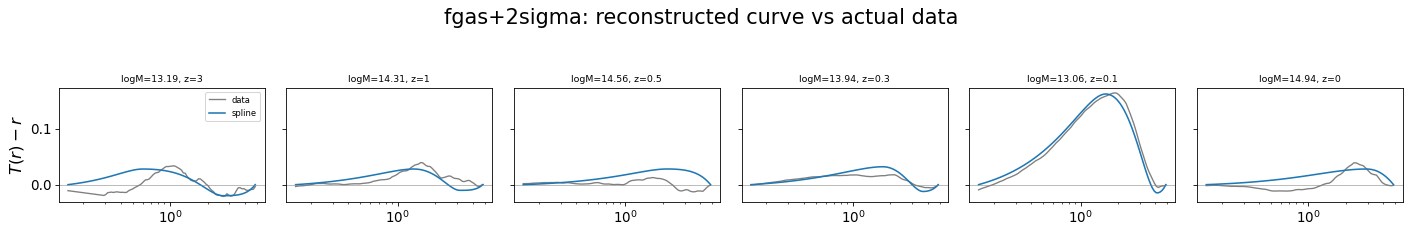

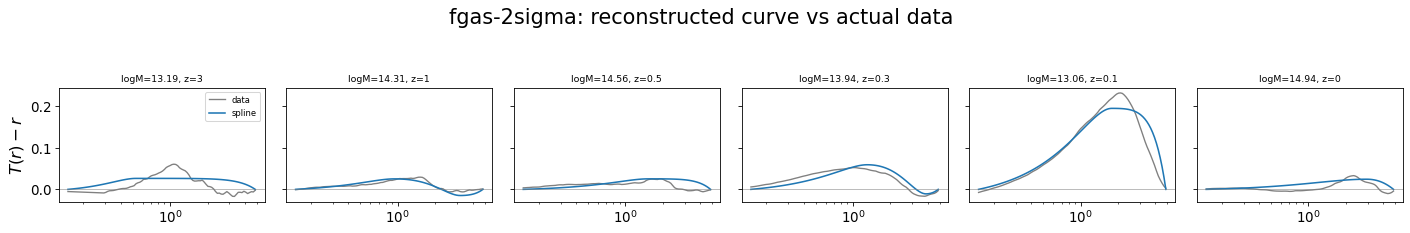

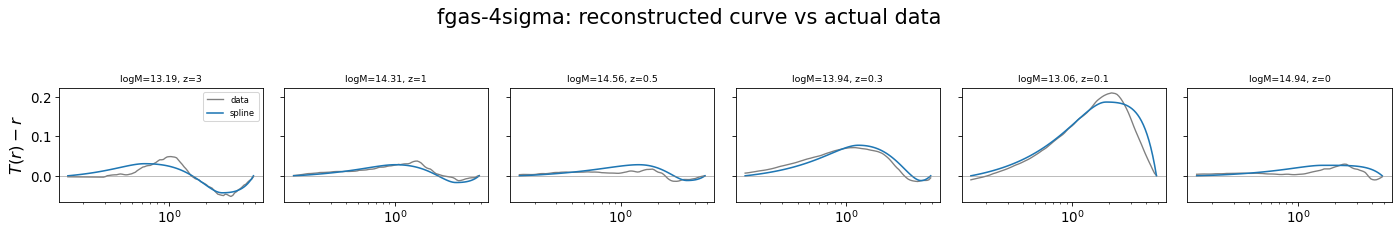

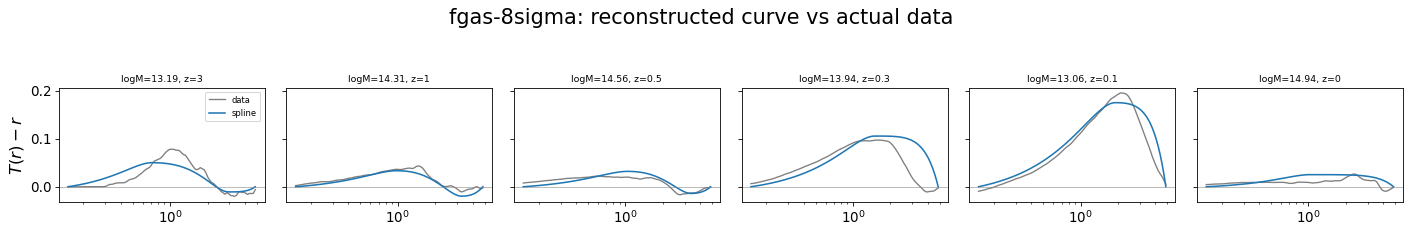

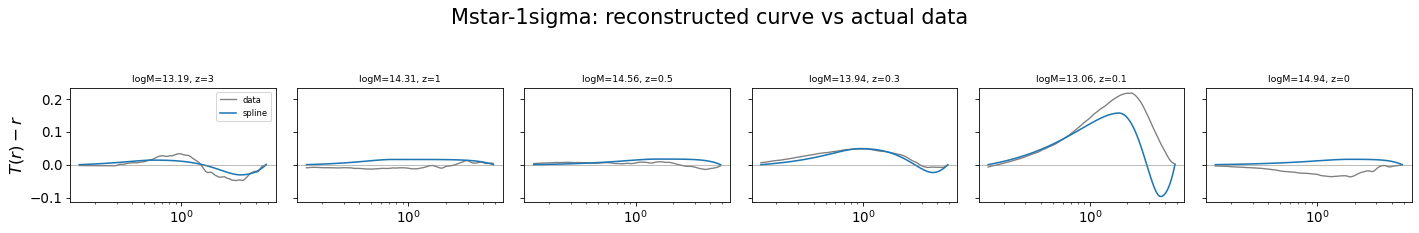

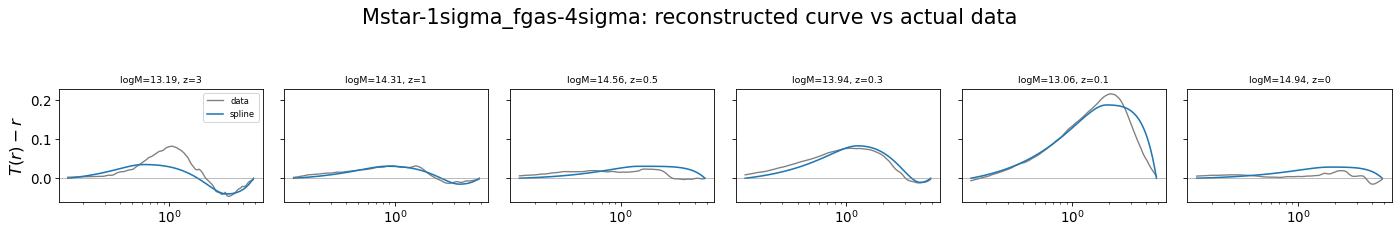

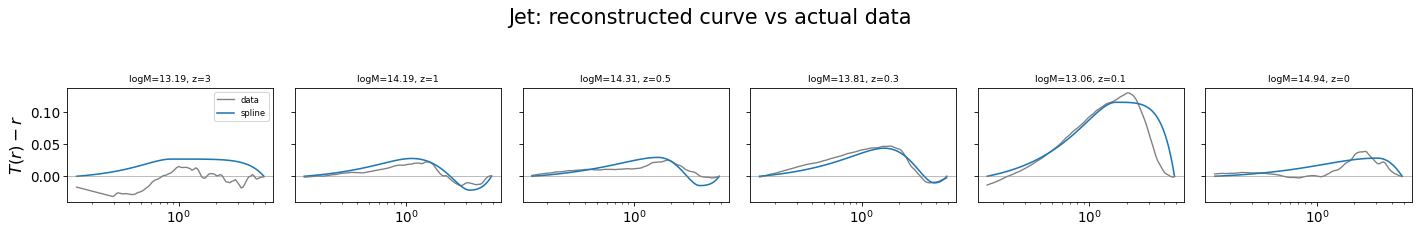

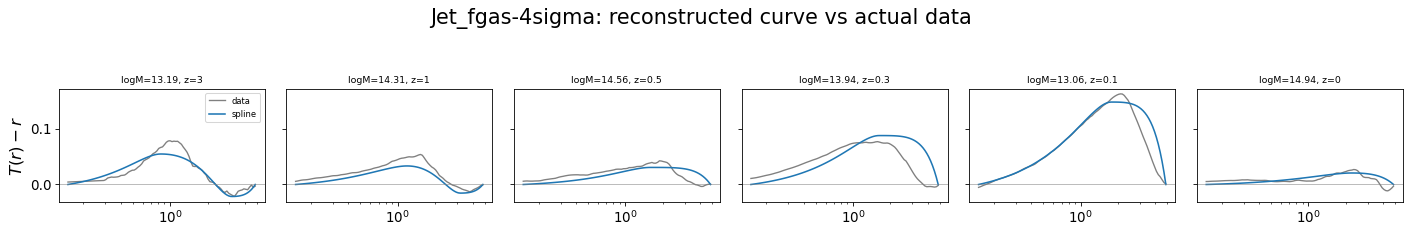

In [16]:
def plot_curve_reconstruction(sim, n_show=6, methods=("spline",)):
    idx_sim = np.where((peaks.sim == sim).values)[0]
    chosen = idx_sim[np.linspace(0, len(idx_sim) - 1, n_show).round().astype(int)]
    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3), sharey=True)
    for ax, i in zip(np.atleast_1d(axes), chosen):
        row = peaks.iloc[i]
        ax.plot(R_GRID, X[i], "-", color="gray", lw=1.3, label="data")
        if "spline" in methods:
            ax.plot(R_GRID, predict_curve_spline(row.sim, row.logM, row.z), "-", color="C0", lw=1.5, label="spline")
        if "gaussmix" in methods:
            ax.plot(R_GRID, predict_curve_gaussmix(row.sim, row.logM, row.z), "--", color="C3", lw=1.5, label="gauss-mix")
        ax.set_xscale("log"); ax.axhline(0, color="gray", lw=.5)
        ax.set_title(f"logM={row.logM:.2f}, z={row.z:g}", fontsize=9)
    axes[0].set_ylabel(r"$T(r)-r$"); axes[0].legend(fontsize=8)
    fig.suptitle(f"{sim}: reconstructed curve vs actual data", y=1.05)
    plt.tight_layout(); plt.show()

for sim in SIMS:
    plot_curve_reconstruction(sim)

## Gaussian-mixture route: extracting bump widths from the raw curves

The sum-of-Gaussians reconstruction needs one more quantity per landmark that isn't fit yet:
its width. Measured directly off each bin's own (already-smoothed) curve as a **FWHM-based
width**: locate the landmark's grid index, run `scipy.signal.peak_widths` at half-height on the
smoothed curve there (negated first for a trough), convert from grid-index units to `r` via the
local grid spacing, and convert half-width-at-half-max to the Gaussian convention `w` (where
`exp(-((r-r0)/w)^2) = 0.5` at `r-r0 = w*sqrt(ln 2)`). Then `width(log M, z)` is fit per sim/role
the same way as every other landmark quantity above, using the same significance masks (a
landmark's width is only meaningful where the landmark itself is significant).

In [17]:
from scipy.signal import peak_widths

def landmark_width(i, r_val, y_val):
    """Gaussian-equivalent width of the feature at r_val on bin i's (smoothed) curve -- reuses
    the same savgol smoothing find_landmark_points used, located via nearest grid index."""
    y_smooth = savgol_filter(X[i], 41, 3)
    j = int(np.argmin(np.abs(R_GRID - r_val)))
    sig = y_smooth if y_val >= 0 else -y_smooth
    try:
        fwhm_idx = peak_widths(sig, [j], rel_height=0.5)[0][0]
        dr_dindex = np.gradient(R_GRID)[j]
        return (fwhm_idx * dr_dindex / 2) / np.sqrt(np.log(2))
    except Exception:
        return np.nan

for role in ["inner", "peak", "outer"]:
    rvals, yvals = peaks[f"r_{role}"].values, peaks[f"y_{role}"].values
    peaks[f"w_{role}"] = [landmark_width(i, r, y) if np.isfinite(r) else np.nan
                          for i, (r, y) in enumerate(zip(rvals, yvals))]

print("median width by role (r units):")
print(peaks[["w_inner", "w_peak", "w_outer"]].median())

def width_func(X, log_w0, b, c):
    logM, z = X
    return np.exp(log_w0 + b * (logM - M_REF) + c * z)

DEFAULT_WIDTH = {role: float(peaks[f"w_{role}"].median()) for role in ["inner", "peak", "outer"]}

width_fits = {}
width_rows = []
for sim in SIMS:
    sub = peaks[peaks.sim == sim]
    logM, z = sub.logM.values, sub.z.values
    width_fits[sim] = {}
    role_masks = [("peak", np.isfinite(sub.w_peak.values) & (sub.n_halos.values >= R_PEAK_NHALOS_FLOOR)),
                  ("inner", np.isfinite(sub.w_inner.values) & (sub.y_inner.values < -R_INNER_AMP_CUT)),
                  ("outer", np.isfinite(sub.w_outer.values) & (sub.y_outer.values < -R_OUTER_AMP_CUT))]
    for role, mask in role_masks:
        y = sub[f"w_{role}"].values
        med = np.nanmedian(y[mask]) if mask.sum() else DEFAULT_WIDTH[role]
        med = med if np.isfinite(med) and med > 0 else DEFAULT_WIDTH[role]
        p0 = [[np.log(med), b0, c0] for b0 in [-0.3, 0, 0.3] for c0 in [-0.3, 0, 0.3]]
        r2_w, popt_w = multistart_fit(width_func, p0, ([-3, -3, -3], [3, 3, 3]), logM, z, y, mask)
        width_fits[sim][role] = popt_w
        width_rows.append(dict(sim=sim, role=role, r2=r2_w, n=int(mask.sum())))

width_r2 = pd.DataFrame(width_rows)
print("\nwidth(logM,z) fit quality:")
print(width_r2.pivot(index="sim", columns="role", values="r2").round(3))

/var/folders/t0/lct46439705461yqnjg81yhc0000gp/T/ipykernel_21023/2253825023.py:10: PeakPropertyWarning: some peaks have a prominence of 0
  fwhm_idx = peak_widths(sig, [j], rel_height=0.5)[0][0]
/var/folders/t0/lct46439705461yqnjg81yhc0000gp/T/ipykernel_21023/2253825023.py:10: PeakPropertyWarning: some peaks have a width of 0
  fwhm_idx = peak_widths(sig, [j], rel_height=0.5)[0][0]


median width by role (r units):
w_inner    0.096821
w_peak     1.325187
w_outer    0.892258
dtype: float64



width(logM,z) fit quality:
role                      inner  outer   peak
sim                                          
Jet                       0.385  0.689  0.648
Jet_fgas-4sigma           0.543  0.396  0.815
Mstar-1sigma              0.367  0.008  0.212
Mstar-1sigma_fgas-4sigma  0.403  0.696  0.608
fgas+2sigma               0.475  0.645  0.530
fgas-2sigma               0.546  0.804  0.559
fgas-4sigma               0.537  0.441  0.615
fgas-8sigma               0.557  0.546  0.686


## Assembling the Gaussian-mixture curve, with the overlap correction

For the (up to 3) existing landmarks at positions `r_i` with target amplitudes `y_i` and fitted
widths `w_i`, a naive `curve(r) = sum_i y_i * exp(-((r-r_i)/w_i)^2)` won't actually hit `y_i` at
`r_i` once bumps overlap -- each bump also picks up a contribution from its neighbors' tails at
that point. Fix: build the small overlap matrix `M_ij = exp(-((r_i-r_j)/w_j)^2)` (contribution
of bump `j` at landmark `i`'s position) and solve `M @ A = y` for corrected amplitudes `A`, so
the sum lands exactly on every `(r_i, y_i)` despite the cross-talk -- this is the "then add the
points" correction. Nothing enforces the curve to hit exactly 0 at the domain edges the way the
spline's boundary anchors do; checked separately below (residual there should be tiny as long
as widths are small relative to distance from the edges).

In [18]:
def eval_width(sim, role, logM, z):
    popt = width_fits[sim].get(role)
    if popt is None:
        return DEFAULT_WIDTH[role]
    w = width_func((np.array([logM]), np.array([z])), *popt)[0]
    return w if np.isfinite(w) and w > 0 else DEFAULT_WIDTH[role]

def predict_curve_gaussmix(sim, logM, z, r_grid=R_GRID):
    pts = predict_landmarks(sim, logM, z)
    rs = np.array([p[1] for p in pts])
    ys = np.array([p[2] for p in pts])
    ws = np.array([eval_width(sim, p[0], logM, z) for p in pts])

    M = np.exp(-((rs[:, None] - rs[None, :]) / ws[None, :]) ** 2)
    try:
        A = np.linalg.solve(M, ys)
    except np.linalg.LinAlgError:
        A, *_ = np.linalg.lstsq(M, ys, rcond=None)

    curve = np.zeros_like(r_grid)
    for A_i, r_i, w_i in zip(A, rs, ws):
        curve = curve + A_i * np.exp(-((r_grid - r_i) / w_i) ** 2)
    return curve

gaussmix_rows = []
edge_residuals = []
for i in range(len(bins_)):
    sim, logM, z = peaks.sim.iloc[i], peaks.logM.iloc[i], peaks.z.iloc[i]
    yhat = predict_curve_gaussmix(sim, logM, z)
    gaussmix_rows.append(dict(sim=sim, r2=r2_score(X[i], yhat)))
    edge_residuals.append(max(abs(yhat[0]), abs(yhat[-1])))
gaussmix_r2 = pd.DataFrame(gaussmix_rows)

print("Gaussian-mixture (overlap-corrected) reconstruction, per sim:")
print(gaussmix_r2.groupby("sim").r2.mean().round(3))
print(f"\noverall mean R^2 = {gaussmix_r2.r2.mean():.3f}")
print(f"max |curve value| at the domain edges (0.15, 4.85) across all bins, "
      f"not enforced by construction: {np.nanmax(edge_residuals):.4f}")

Gaussian-mixture (overlap-corrected) reconstruction, per sim:
sim
Jet                         0.255
Jet_fgas-4sigma             0.621
Mstar-1sigma               -1.007
Mstar-1sigma_fgas-4sigma    0.590
fgas+2sigma                 0.199
fgas-2sigma                 0.545
fgas-4sigma                 0.489
fgas-8sigma                 0.632
Name: r2, dtype: float64

overall mean R^2 = 0.291
max |curve value| at the domain edges (0.15, 4.85) across all bins, not enforced by construction: 0.0895


full-curve reconstruction R^2, spline vs Gaussian-mixture:
                          spline  gaussmix
sim                                       
fgas+2sigma                0.266     0.199
fgas-2sigma                0.438     0.545
fgas-4sigma                0.387     0.489
fgas-8sigma                0.508     0.632
Mstar-1sigma              -0.816    -1.007
Mstar-1sigma_fgas-4sigma   0.389     0.590
Jet                        0.223     0.255
Jet_fgas-4sigma            0.268     0.621

mean: {'spline': 0.208, 'gaussmix': 0.291}


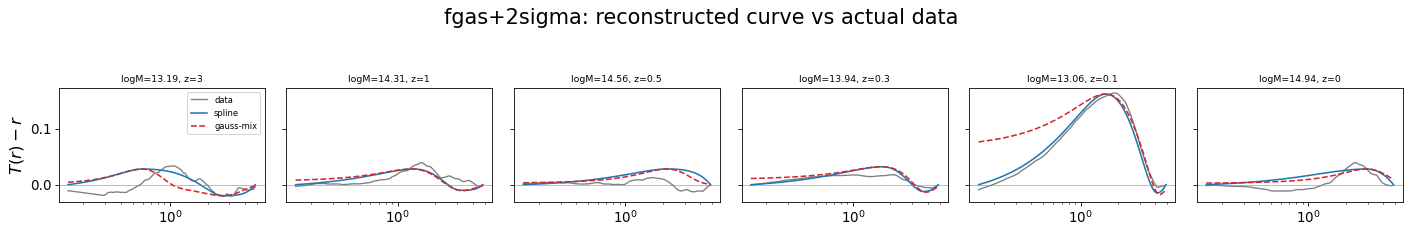

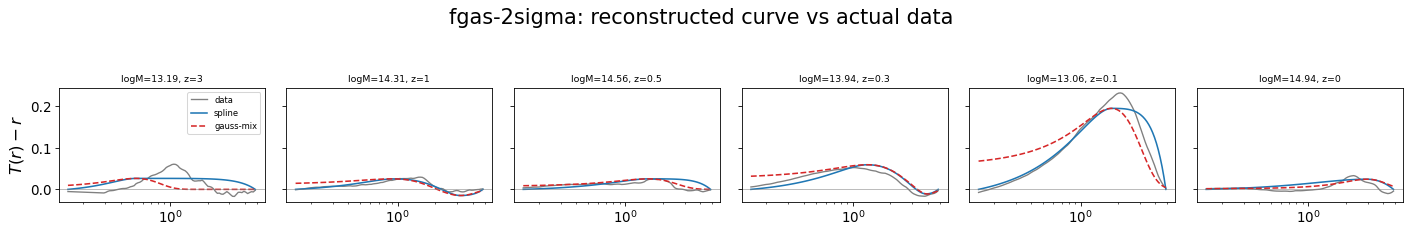

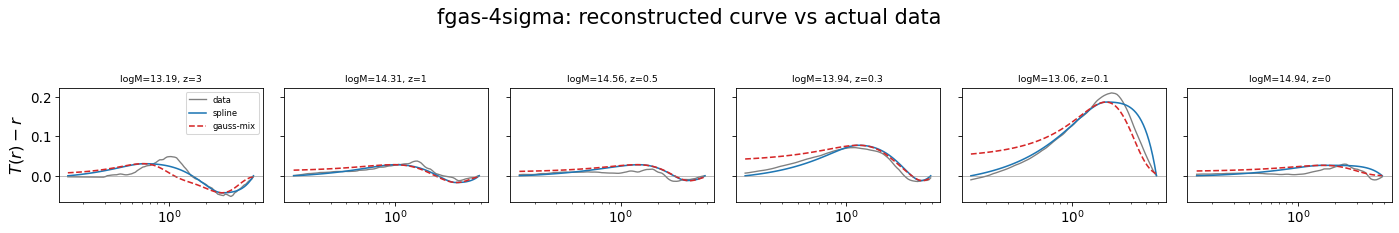

In [19]:
recon_compare = pd.DataFrame({
    "spline": spline_r2.groupby("sim").r2.mean(),
    "gaussmix": gaussmix_r2.groupby("sim").r2.mean(),
}).reindex(SIMS)
print("full-curve reconstruction R^2, spline vs Gaussian-mixture:")
print(recon_compare.round(3))
print("\nmean:", recon_compare.mean().round(3).to_dict())

for sim in SIMS[:3]:
    plot_curve_reconstruction(sim, methods=("spline", "gaussmix"))

### Reality check: is the low R^2 from landmark prediction error, or from the reconstruction shape?

Both full-curve R^2's above (0.21 spline, 0.29 gauss-mix) are much lower than any individual
landmark quantity's own R^2 (0.44-0.98). Before drawing conclusions, that gap needs to be
split into two very different possible causes: **(a)** the fitted `(logM,z) -> landmark`
functions mispredicting *where/how tall* the landmarks are, vs. **(b)** the spline/gauss-mix
*shape assumption* between landmarks being wrong, or simply the fact that `X[i]` is the **raw,
unsmoothed** per-radius data (real bootstrap noise at every one of the 100 grid points, not
just at the landmarks) -- no smooth model, however perfect its landmark predictions, can track
point-to-point noise it was never meant to fit.

Isolate this by re-running both reconstructions using each bin's own **measured** landmark
points (`peak_results`, the actual detected `(r, y)` for that specific curve) instead of the
fitted model's prediction -- this measures the reconstruction method's ceiling given perfect
landmark knowledge.

In [20]:
def oracle_points(i):
    """This bin's OWN measured landmarks (from peak_results), not the fitted model's prediction."""
    (r_in, y_in), (r_pk, y_pk), (r_out, y_out) = peak_results[i]
    pts = [("peak", r_pk, y_pk)]
    if np.isfinite(r_in) and y_in < -R_INNER_AMP_CUT:
        pts.append(("inner", r_in, y_in))
    if np.isfinite(r_out) and y_out < -R_OUTER_AMP_CUT:
        pts.append(("outer", r_out, y_out))
    return pts

def curve_spline_from_pts(pts, r_grid=R_GRID):
    rs = np.array([0.15] + [p[1] for p in pts] + [4.85])
    ys = np.array([0.0] + [p[2] for p in pts] + [0.0])
    order = np.argsort(rs); rs, ys = rs[order], ys[order]
    keep = np.concatenate([[True], np.diff(rs) > 1e-6])
    return PchipInterpolator(rs[keep], ys[keep])(r_grid)

def curve_gaussmix_from_pts(i, pts, r_grid=R_GRID):
    rs = np.array([p[1] for p in pts])
    ys = np.array([p[2] for p in pts])
    ws = np.array([peaks[f"w_{p[0]}"].iloc[i] for p in pts])
    ws = np.array([w if np.isfinite(w) and w > 0 else DEFAULT_WIDTH[p[0]] for w, p in zip(ws, pts)])
    M = np.exp(-((rs[:, None] - rs[None, :]) / ws[None, :]) ** 2)
    try:
        A = np.linalg.solve(M, ys)
    except np.linalg.LinAlgError:
        A, *_ = np.linalg.lstsq(M, ys, rcond=None)
    curve = np.zeros_like(r_grid)
    for A_i, r_i, w_i in zip(A, rs, ws):
        curve = curve + A_i * np.exp(-((r_grid - r_i) / w_i) ** 2)
    return curve

oracle_rows = []
for i in range(len(bins_)):
    sim = peaks.sim.iloc[i]
    pts = oracle_points(i)
    r2_sp = r2_score(X[i], curve_spline_from_pts(pts))
    r2_gm = r2_score(X[i], curve_gaussmix_from_pts(i, pts))
    oracle_rows.append(dict(sim=sim, spline_oracle=r2_sp, gaussmix_oracle=r2_gm))
oracle_r2 = pd.DataFrame(oracle_rows)

print("Oracle test: reconstruction quality using each bin's OWN measured landmarks (isolates")
print("shape-reconstruction + noise-floor error from the fitted model's (logM,z) prediction error):")
print(oracle_r2.groupby("sim").mean(numeric_only=True).round(3))
print("\nmean:", oracle_r2.mean(numeric_only=True).round(3).to_dict())

Oracle test: reconstruction quality using each bin's OWN measured landmarks (isolates
shape-reconstruction + noise-floor error from the fitted model's (logM,z) prediction error):
                          spline_oracle  gaussmix_oracle
sim                                                     
Jet                               0.450            0.591
Jet_fgas-4sigma                   0.417            0.757
Mstar-1sigma                      0.370            0.689
Mstar-1sigma_fgas-4sigma          0.537            0.734
fgas+2sigma                       0.415            0.609
fgas-2sigma                       0.542            0.689
fgas-4sigma                       0.578            0.723
fgas-8sigma                       0.577            0.739

mean: {'spline_oracle': 0.486, 'gaussmix_oracle': 0.692}


### Takeaway: gauss-mix is the better shape, but landmark-prediction error dominates

The oracle test cleanly separates the two error sources:

- **Reconstruction shape, given perfect landmark knowledge**: gauss-mix reaches mean R^2
  **0.69** vs. the spline's **0.49** -- the physical bumps are smoother/more Gaussian-like than
  a monotone spline through only 3 points can represent, especially in how it handles curvature
  near a peak. **Gauss-mix is the better reconstruction method** and is what should be used
  going forward.
- **Landmark-prediction error** (the fitted `(logM,z) -> landmark` functions vs. each bin's own
  measured landmarks) accounts for a much bigger drop: gauss-mix falls from 0.69 (oracle) to
  **0.29** (fitted model) -- a ~0.40 hit. Small errors in a fitted landmark's position/amplitude
  compound into large *pointwise* curve error because the features are narrow relative to the
  full domain -- being off by a bit in `r_peak` moves the whole bump, which costs far more R^2
  than the same-sized error in a broad, smoothly-varying quantity would. This is the dominant
  bottleneck, not the interpolation scheme.
- `Mstar-1sigma`'s full-curve reconstruction was strongly *negative* under the fitted model but
  reasonable under the oracle (0.37 spline, 0.69 gauss-mix) -- consistent with it independently
  being the worst-fit sim on nearly every individual landmark throughout this notebook. Several
  moderately-imperfect landmark fits compound into a much worse full curve for that one sim.

**Practical implication**: use `predict_curve_gaussmix` as the OT map generator. But the
fitted 6-function model, applied out-of-sample from `(sim, logM, z)` alone, currently
reconstructs full curves with only middling fidelity (mean R^2 ~0.3) -- the highest-leverage
next step for improving actual map quality is tightening the individual landmark `(logM,z)`
fits (or accepting that positional precision matters more than the R^2 of any one landmark
quantity suggests), not further refining the interpolation between them.

## Grid view: fitted-model spline reconstruction vs the actual OT maps, with bootstrap error bounds

Using the current fits as-is (no changes yet from the improvement ideas above) -- for each sim,
a grid over mass (columns) and z (rows), each panel showing the actual measured curve with a
shaded +-1sigma bootstrap error band, overlaid with `predict_curve_spline`'s reconstruction
built from the fitted model's 3 landmark points at that bin's `(logM, z)`. This is the direct
visual version of the R^2 numbers above -- lets us see *where* (which masses/z/sims) the
reconstruction tracks the data within its own noise, and where it's off by more than
measurement error can explain, before deciding whether the improvement ideas are worth the
effort.

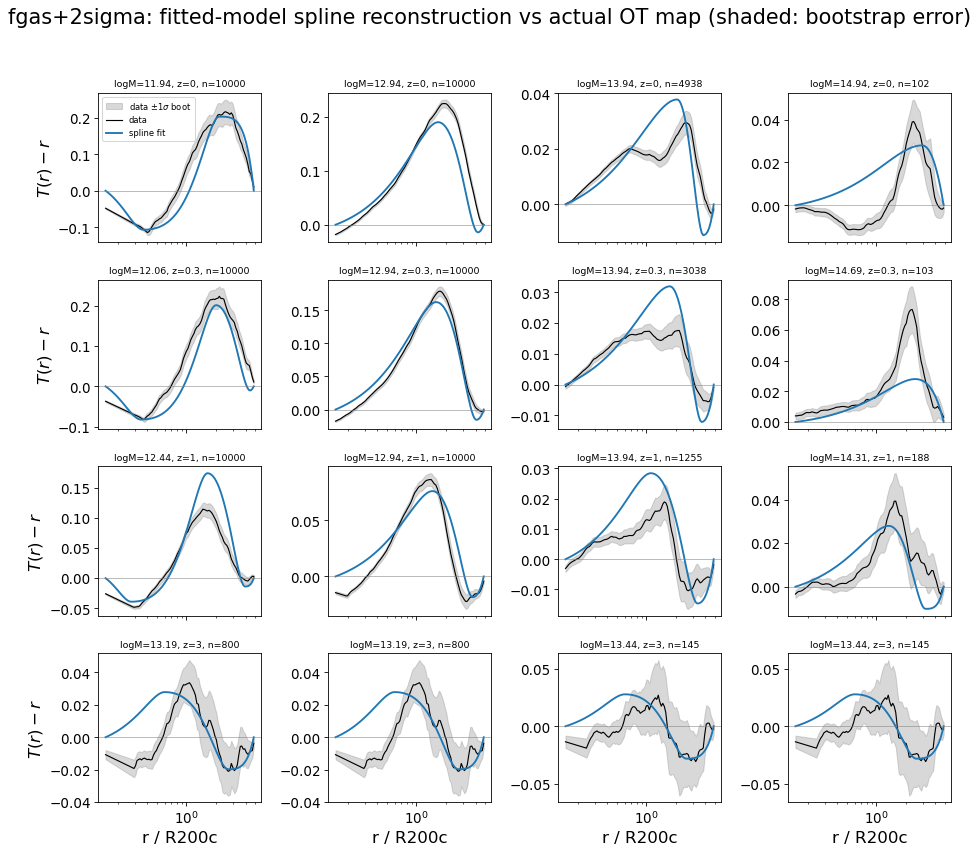

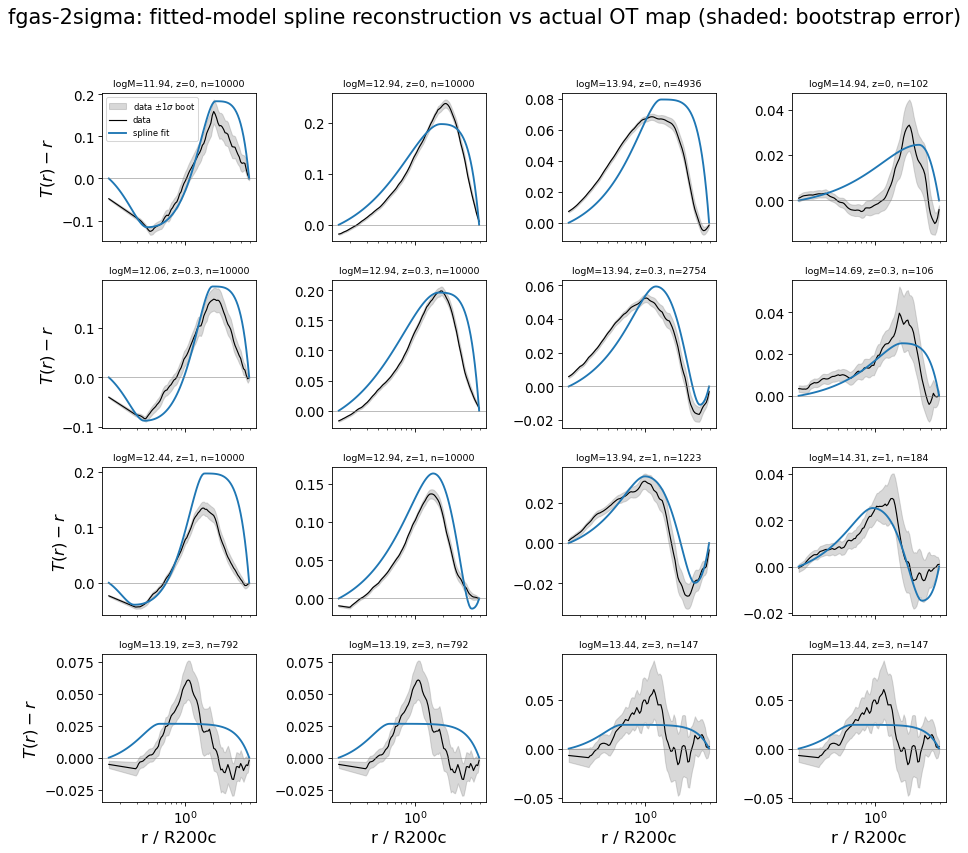

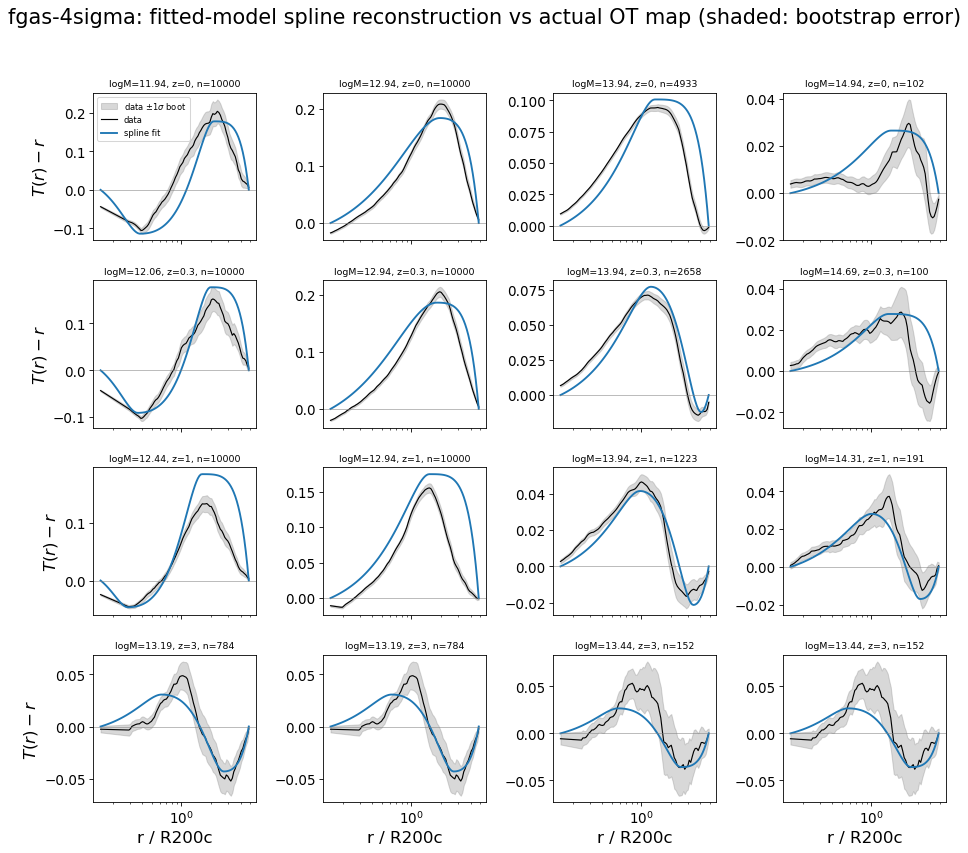

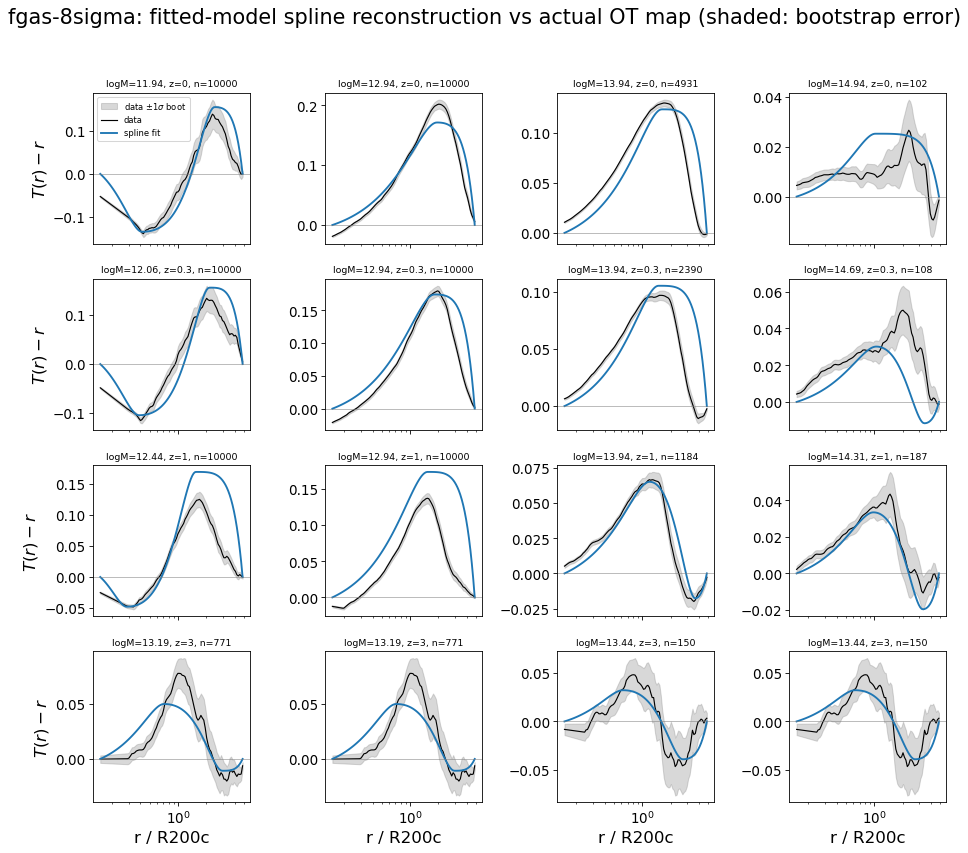

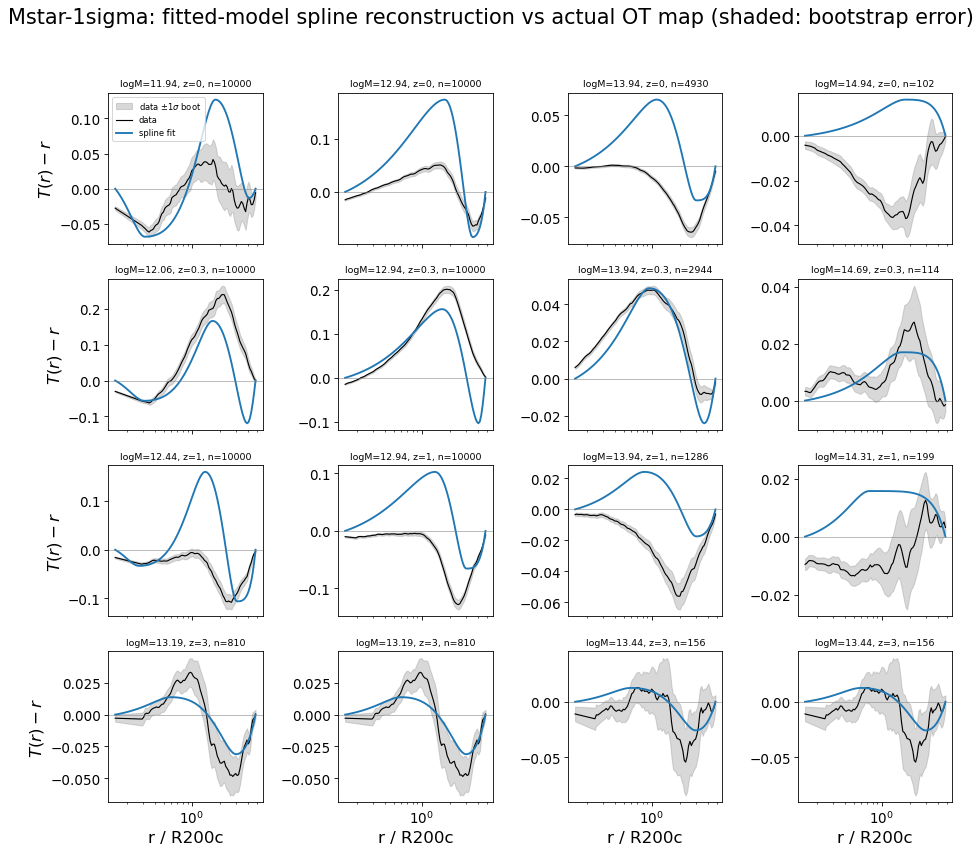

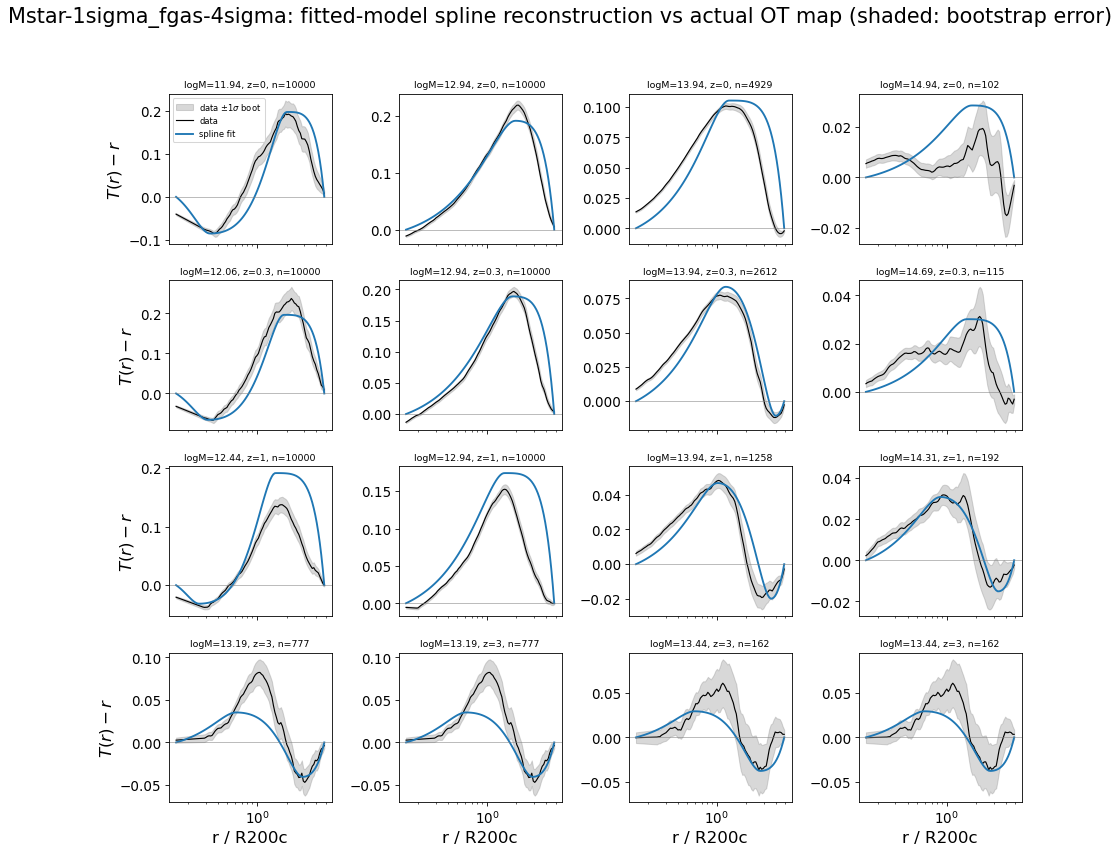

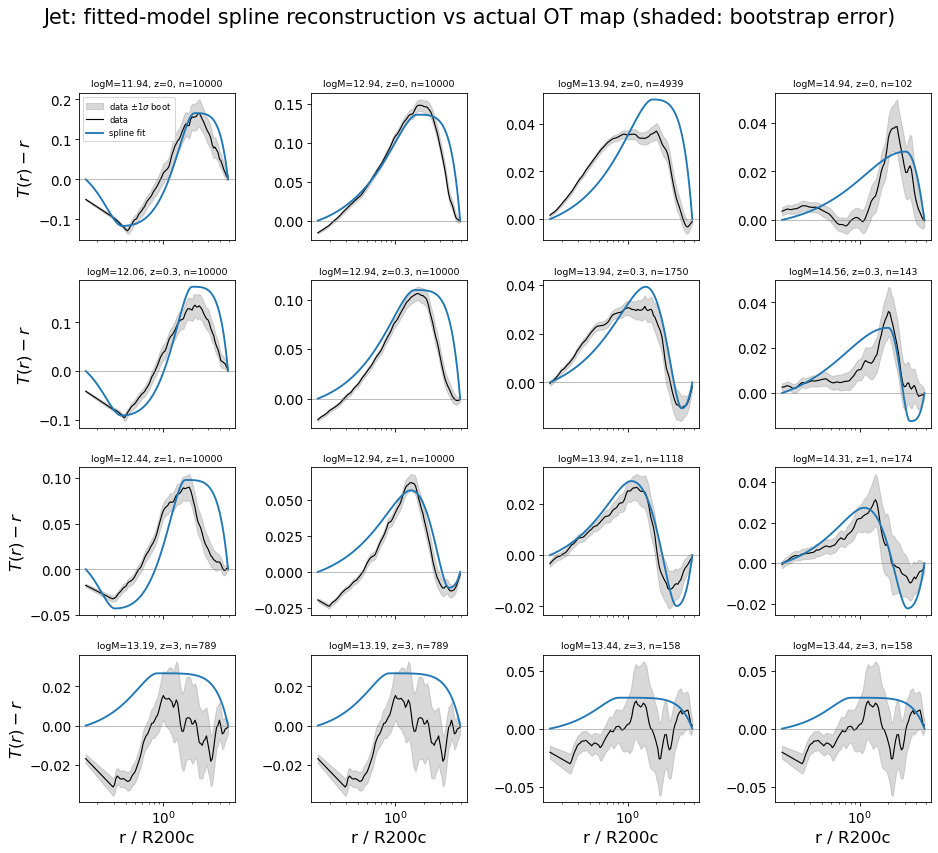

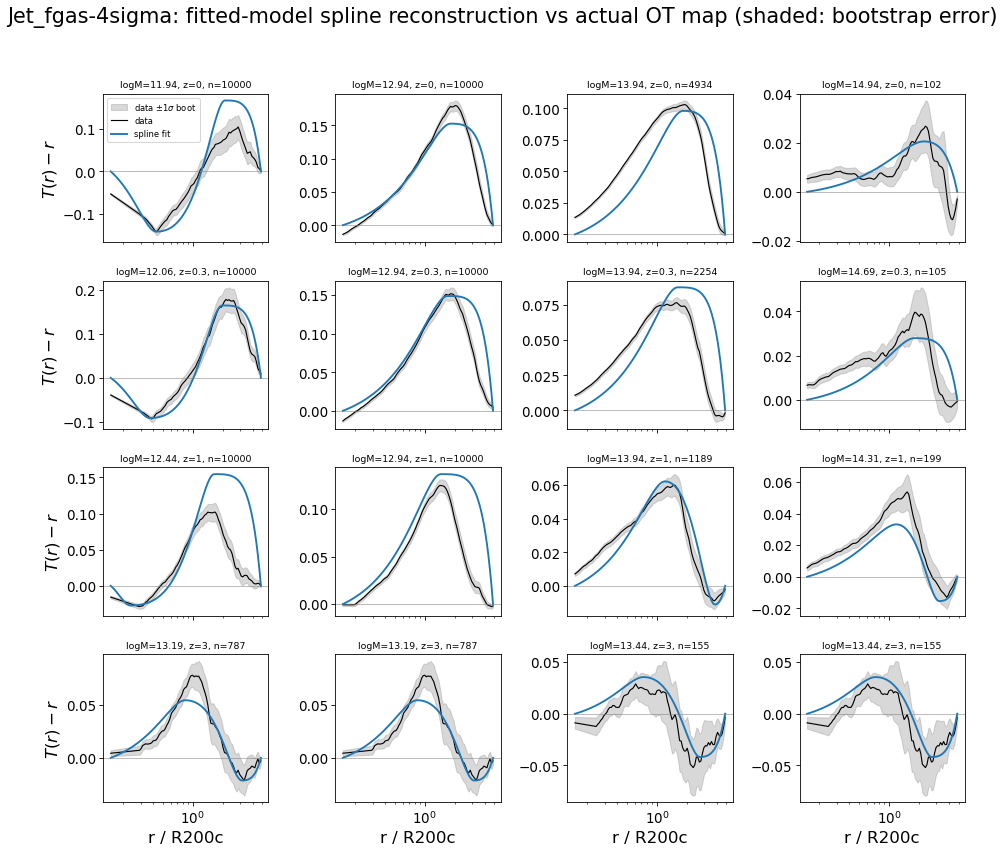

In [21]:
def plot_curve_grid(sim, n_mass=4, n_z=4):
    """Grid of the fitted model's spline reconstruction vs the actual OT amplitude curve, with
    a shaded +-1sigma bootstrap error band -- rows: z (top=low z), cols: mass (left=low mass)."""
    idx_sim = np.where((peaks.sim == sim).values)[0]
    if len(idx_sim) == 0:
        print(f"no bins for {sim}"); return
    zs = sorted({bins_[i]["z"] for i in idx_sim})
    z_targets = [zs[i] for i in sorted(set(np.linspace(0, len(zs) - 1, min(n_z, len(zs))).round().astype(int)))]
    masses = sorted({bins_[i]["logM"] for i in idx_sim})
    m_targets = [masses[i] for i in sorted(set(np.linspace(0, len(masses) - 1, min(n_mass, len(masses))).round().astype(int)))]

    nrows, ncols = len(z_targets), len(m_targets)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.8 * nrows), sharex=True)
    axes = np.atleast_2d(axes)
    for i, z_t in enumerate(z_targets):
        for j, m_t in enumerate(m_targets):
            ax = axes[i, j]
            cand = [k for k in idx_sim if bins_[k]["z"] == z_t]
            if not cand:
                ax.axis("off"); continue
            k = min(cand, key=lambda k: abs(bins_[k]["logM"] - m_t))
            b = bins_[k]
            std = STD_GRID[k]
            ax.fill_between(R_GRID, X[k] - std, X[k] + std, color="gray", alpha=0.3, label=r"data $\pm1\sigma$ boot")
            ax.plot(R_GRID, X[k], "-", color="k", lw=1.1, label="data")
            yhat = predict_curve_spline(sim, b["logM"], b["z"])
            ax.plot(R_GRID, yhat, "-", color="C0", lw=1.8, label="spline fit")
            ax.set_xscale("log"); ax.axhline(0, color="gray", lw=.5)
            ax.set_title(f"logM={b['logM']:.2f}, z={b['z']:g}, n={b['n_halos']}", fontsize=9)
    for ax in axes[-1, :]:
        ax.set_xlabel("r / R200c")
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$T(r)-r$")
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"{sim}: fitted-model spline reconstruction vs actual OT map (shaded: bootstrap error)", y=1.02)
    plt.tight_layout(); plt.show()

for sim in SIMS:
    plot_curve_grid(sim)

## Profile complexity map: how many landmark points are needed, per sim

Same idea as the "how many Gaussians needed" complexity map -- our analog is `n_real_peaks`,
the count of significant landmark points (0-3: `peak` alone, or with `inner`/`outer` also
significant) already computed when the turning points were detected. One panel per sim,
`z` vs `log M`, colored by that count -- shows where in `(log M, z)` a single bump suffices
vs. where the outer/inner features kick in, and whether that boundary shifts with feedback
strength across sims.

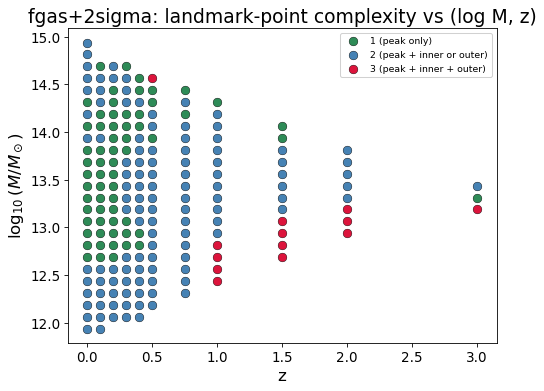

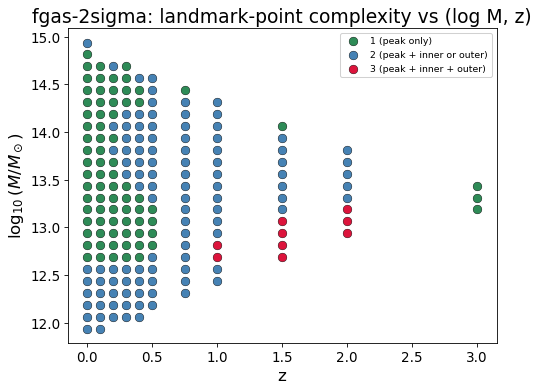

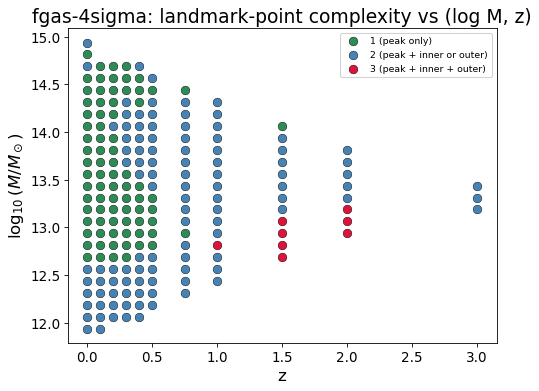

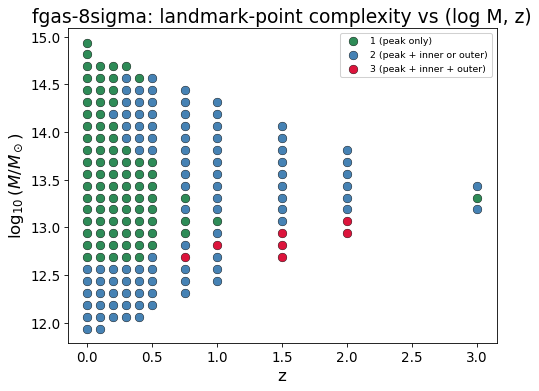

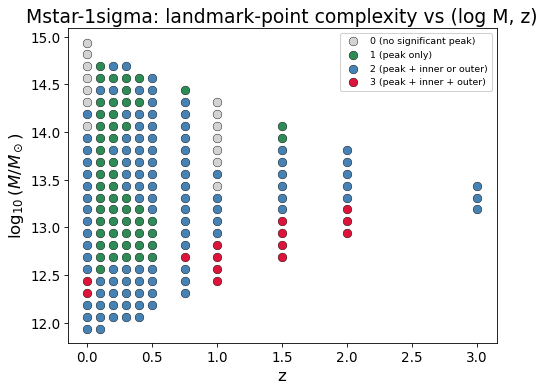

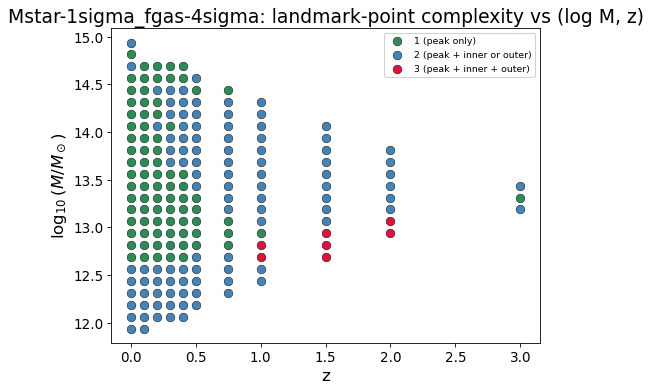

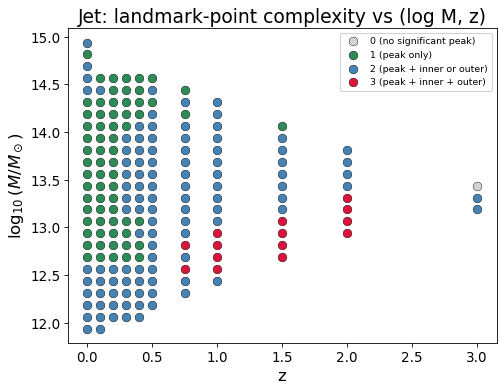

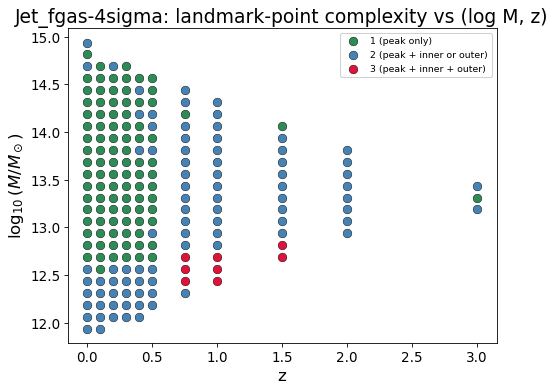

In [22]:
peaks["n_peaks"] = n_real_peaks

def plot_complexity_grid(sim):
    sub = peaks[peaks.sim == sim]
    colors = {0: "lightgray", 1: "seagreen", 2: "steelblue", 3: "crimson"}
    labels = {0: "0 (no significant peak)", 1: "1 (peak only)",
              2: "2 (peak + inner or outer)", 3: "3 (peak + inner + outer)"}
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for n in [0, 1, 2, 3]:
        s = sub[sub.n_peaks == n]
        if len(s):
            ax.scatter(s.z, s.logM, c=colors[n], s=70, edgecolor="k", linewidth=0.4, label=labels[n], zorder=3 - n * 0 + (n == 0) * -1)
    ax.set_xlabel("z"); ax.set_ylabel(r"$\log_{10}(M/M_\odot)$")
    ax.set_title(f"{sim}: landmark-point complexity vs (log M, z)")
    ax.legend(fontsize=9, loc="upper right", framealpha=0.9)
    plt.tight_layout(); plt.show()

for sim in SIMS:
    plot_complexity_grid(sim)